# Évaluation des modèles

CSI 4506 - automne 2026

Marcel Turcotte  
Version: août 9, 2026 11h56

# Préambule

## Message du jour

<https://youtu.be/sDZ1j0J-fe8>

[Demis Hassabis : Le PDG qui travaille à résoudre le cancer avec
l’IA](https://youtu.be/sDZ1j0J-fe8), Bloomberg Technology, 2025-09-14.

Dans une récente interview avec Bloomberg Technology, Demis Hassabis
discute du travail innovant d’Isomorphic Labs dans l’accélération
significative des processus de développement de médicaments. Voici un
résumé des réalisations notables de Hassabis :

- Prodige des échecs dès son jeune âge, Hassabis a commencé à jouer à
  quatre ans et a atteint un classement Elo d’environ 2300 à l’âge de 13
  ans.
- Il a cofondé [DeepMind](https://deepmind.google) en 2010 aux côtés de
  Shane Legg et Mustafa Suleyman, où il est actuellement PDG.
- Sous sa direction, DeepMind a été à l’avant-garde de plusieurs
  avancées révolutionnaires en intelligence artificielle, y compris le
  développement de
  [AlphaGo](https://deepmind.google/research/projects/alphago/) et,
  notamment, [AlphaFold et
  AlphaFold2](https://deepmind.google/science/alphafold/), qui sont
  essentiels dans la prédiction de la structure des protéines.
- En reconnaissance de ses contributions à la prédiction de la structure
  des protéines, Hassabis a reçu le [Prix Nobel de Chimie en
  2024](https://www.nobelprize.org/prizes/chemistry/2024/hassabis/facts/).
- En 2021, il a fondé [Isomorphic Labs](https://www.isomorphiclabs.com),
  qui se concentre sur l’application de l’IA à la découverte de
  médicaments et à la science translationnelle.
- [“The Thinking Game”](https://thinkinggamefilm.com) est un
  documentaire qui explore la vie de Demis Hassabis, l’évolution de
  DeepMind, et la quête de l’intelligence artificielle générale (IAG).

Dans un domaine connexe, un article intitulé “[Quelles maladies
aurez-vous dans 20 ans ? Cette IA prédit avec précision vos
risques](https://www.nature.com/articles/d41586-025-02993-x)” a été
publié dans Nature le 17 septembre 2025. Ce bref article d’actualité
discute de Delphi-2M, un grand modèle de langage conçu pour analyser les
dossiers médicaux et les facteurs de mode de vie d’un individu afin de
fournir des évaluations de risque pour plus de 1 000 maladies. Un
[podcast](https://www.nature.com/articles/d41586-025-03026-3) est
également disponible pour plus de perspectives.

## Résumé

Ce cours aborde l’évaluation des modèles de classification, en se
concentrant sur les matrices de confusion et les métriques clés :
exactitude, précision, rappel et score $F_1$. Il traite des limites de
l’exactitude dans les ensembles de données déséquilibrés, en
introduisant les moyennes micro et macro. Le compromis précision-rappel
et l’analyse ROC, y compris l’AUC, sont également explorés. Des
perspectives pratiques sont fournies à travers des implémentations en
Python comme la régression logistique via la descente de gradient.

## Résultats d’apprentissage

- **Décrire** la structure et le rôle de la matrice de confusion dans
  l’évaluation des modèles.
- **Calculer** et **interpréter** l’exactitude, la précision, le rappel
  et le score $F_1$.
- **Identifier** les pièges de l’utilisation de l’exactitude avec des
  ensembles de données déséquilibrés.
- **Différencier** entre les moyennes micro et macro pour les métriques
  de performance.
- **Analyser** les compromis précision-rappel et **construire** des
  courbes ROC, y compris le calcul de l’AUC.
- **Implémenter** le calcul des courbes ROC et de l’AUC en Python.

# Mesures de performance

## Matrice de confusion

|                        | **Positif** (**Prédit**) | **Négatif** (**Prédit**) |
|------------------------|------------------------|------------------------|
| **Positif** (**Réel**) | Vrai positif (VP)        | Faux négatif (FN)        |
| **Négatif** (**Réel**) | Faux positif (FP)        | Vrai négatif (VN)        |

Une **matrice de confusion** est un tableau résumant la performance d’un
algorithme de classification (ici pour une tâche de classification
binaire).

- Dans l’analyse statistique, les **faux positifs (FP)** sont
  communément appelés **erreurs de type I**, et les **faux négatifs
  (FN)** sont connus sous le nom d’**erreurs de type II**.
- Les éléments de la diagonale représentent les résultats correctement
  prédits, à savoir les vrais positifs (VP) et les vrais négatifs (VN).
- À l’inverse, les éléments hors diagonale correspondent aux prédictions
  incorrectes, spécifiquement les faux positifs (FP) et les faux
  négatifs (FN).
- La **matrice de confusion** encapsule toutes les informations
  essentielles nécessaires pour évaluer la performance d’un modèle de
  classification.
- Bien que la matrice de confusion fournisse une vue d’ensemble, des
  **mesures plus concises** telles que l’**exactitude**, la
  **précision**, le **rappel**, et le **score F$_1$** sont souvent plus
  intuitives et pratiques pour résumer la performance du modèle.

## ConfusionMatrixDisplay

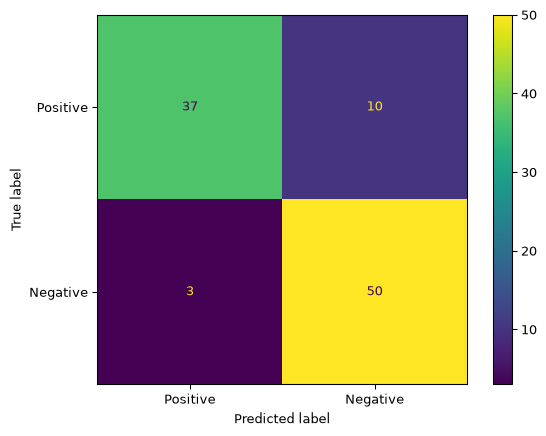

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

seed = 42

X, y = make_classification(n_samples = 500, random_state=seed)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

clf = LogisticRegression(random_state=seed)

clf.fit(X_train, y_train)

predictions = clf.predict(X_test)

cm = confusion_matrix(y_test, predictions, labels=[1, 0])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Positive", "Negative"])

disp.plot()
plt.show()

Nous utilisons la fonction `make_classification` pour générer un jeu de
données synthétique, qui est ensuite analysé à l’aide d’un modèle de
`LogisticRegression`. Pour les deux fonctions `confusion_matrix` et
`ConfusionMatrixDisplay`, nous configurons les étiquettes pour nous
assurer que la classe ‘Positive’ précède, en accord avec les données
tabulaires présentées à l’écran précédent. La matrice de confusion
résultante donne les valeurs suivantes : Vrais Positifs (VP) = 37, Faux
Négatifs (FN) = 10, Faux Positifs (FP) = 3, et Vrais Négatifs (VN) = 50.

## Matrice de confusion

Étant donné un ensemble de test avec $N$ exemples et un classificateur
$h(x) :$

$$
C_{i,j} = \sum_{k = 1}^N [y_k = i \wedge h(x_k) = j]
$$

Où $C$ est une matrice $l \times l$, pour un ensemble de données avec
$l$ classes.

Une matrice de confusion $C$ est définie de telle sorte que chaque
élément $C_{i,j}$ représente le nombre d’observations appartenant
réellement à la classe $i$ mais prédites comme appartenant à la classe
$j$.

Examinons maintenant le cas général d’une matrice de confusion avec $l$
classes, qui peut initialement sembler “confus” à comprendre.

## Matrice de confusion

- Le nombre total d’exemples de la classe (réelle) $i$ est $$
  C_{i \cdot} = \sum_{j=1}^l C_{i,j}
  $$

- Le nombre total d’exemples assignés à la classe (prédite) $j$ par le
  classificateur $h$ est $$
  C_{\cdot j} = \sum_{i=1}^l C_{i,j}
  $$

## Matrice de confusion

- Les termes sur la diagonale indiquent le nombre total d’exemples
  classés correctement par le classificateur $h$. Ainsi, le nombre
  d’exemples correctement classés est $$
  \sum_{i=1}^l C_{i,i}
  $$

- Les termes non-diagonaux représentent les erreurs de classification.

## Matrice de confusion - multi-classes

Pour évaluer la performance dans un contexte **multi-classes**, on
dérive généralement des métriques **“un-contre-tous”** pour **chaque
classe** à partir de la matrice de confusion. Ces métriques sont ensuite
**moyennées** en utilisant des schémas de pondération spécifiques.

## Matrice de confusion - multi-classes

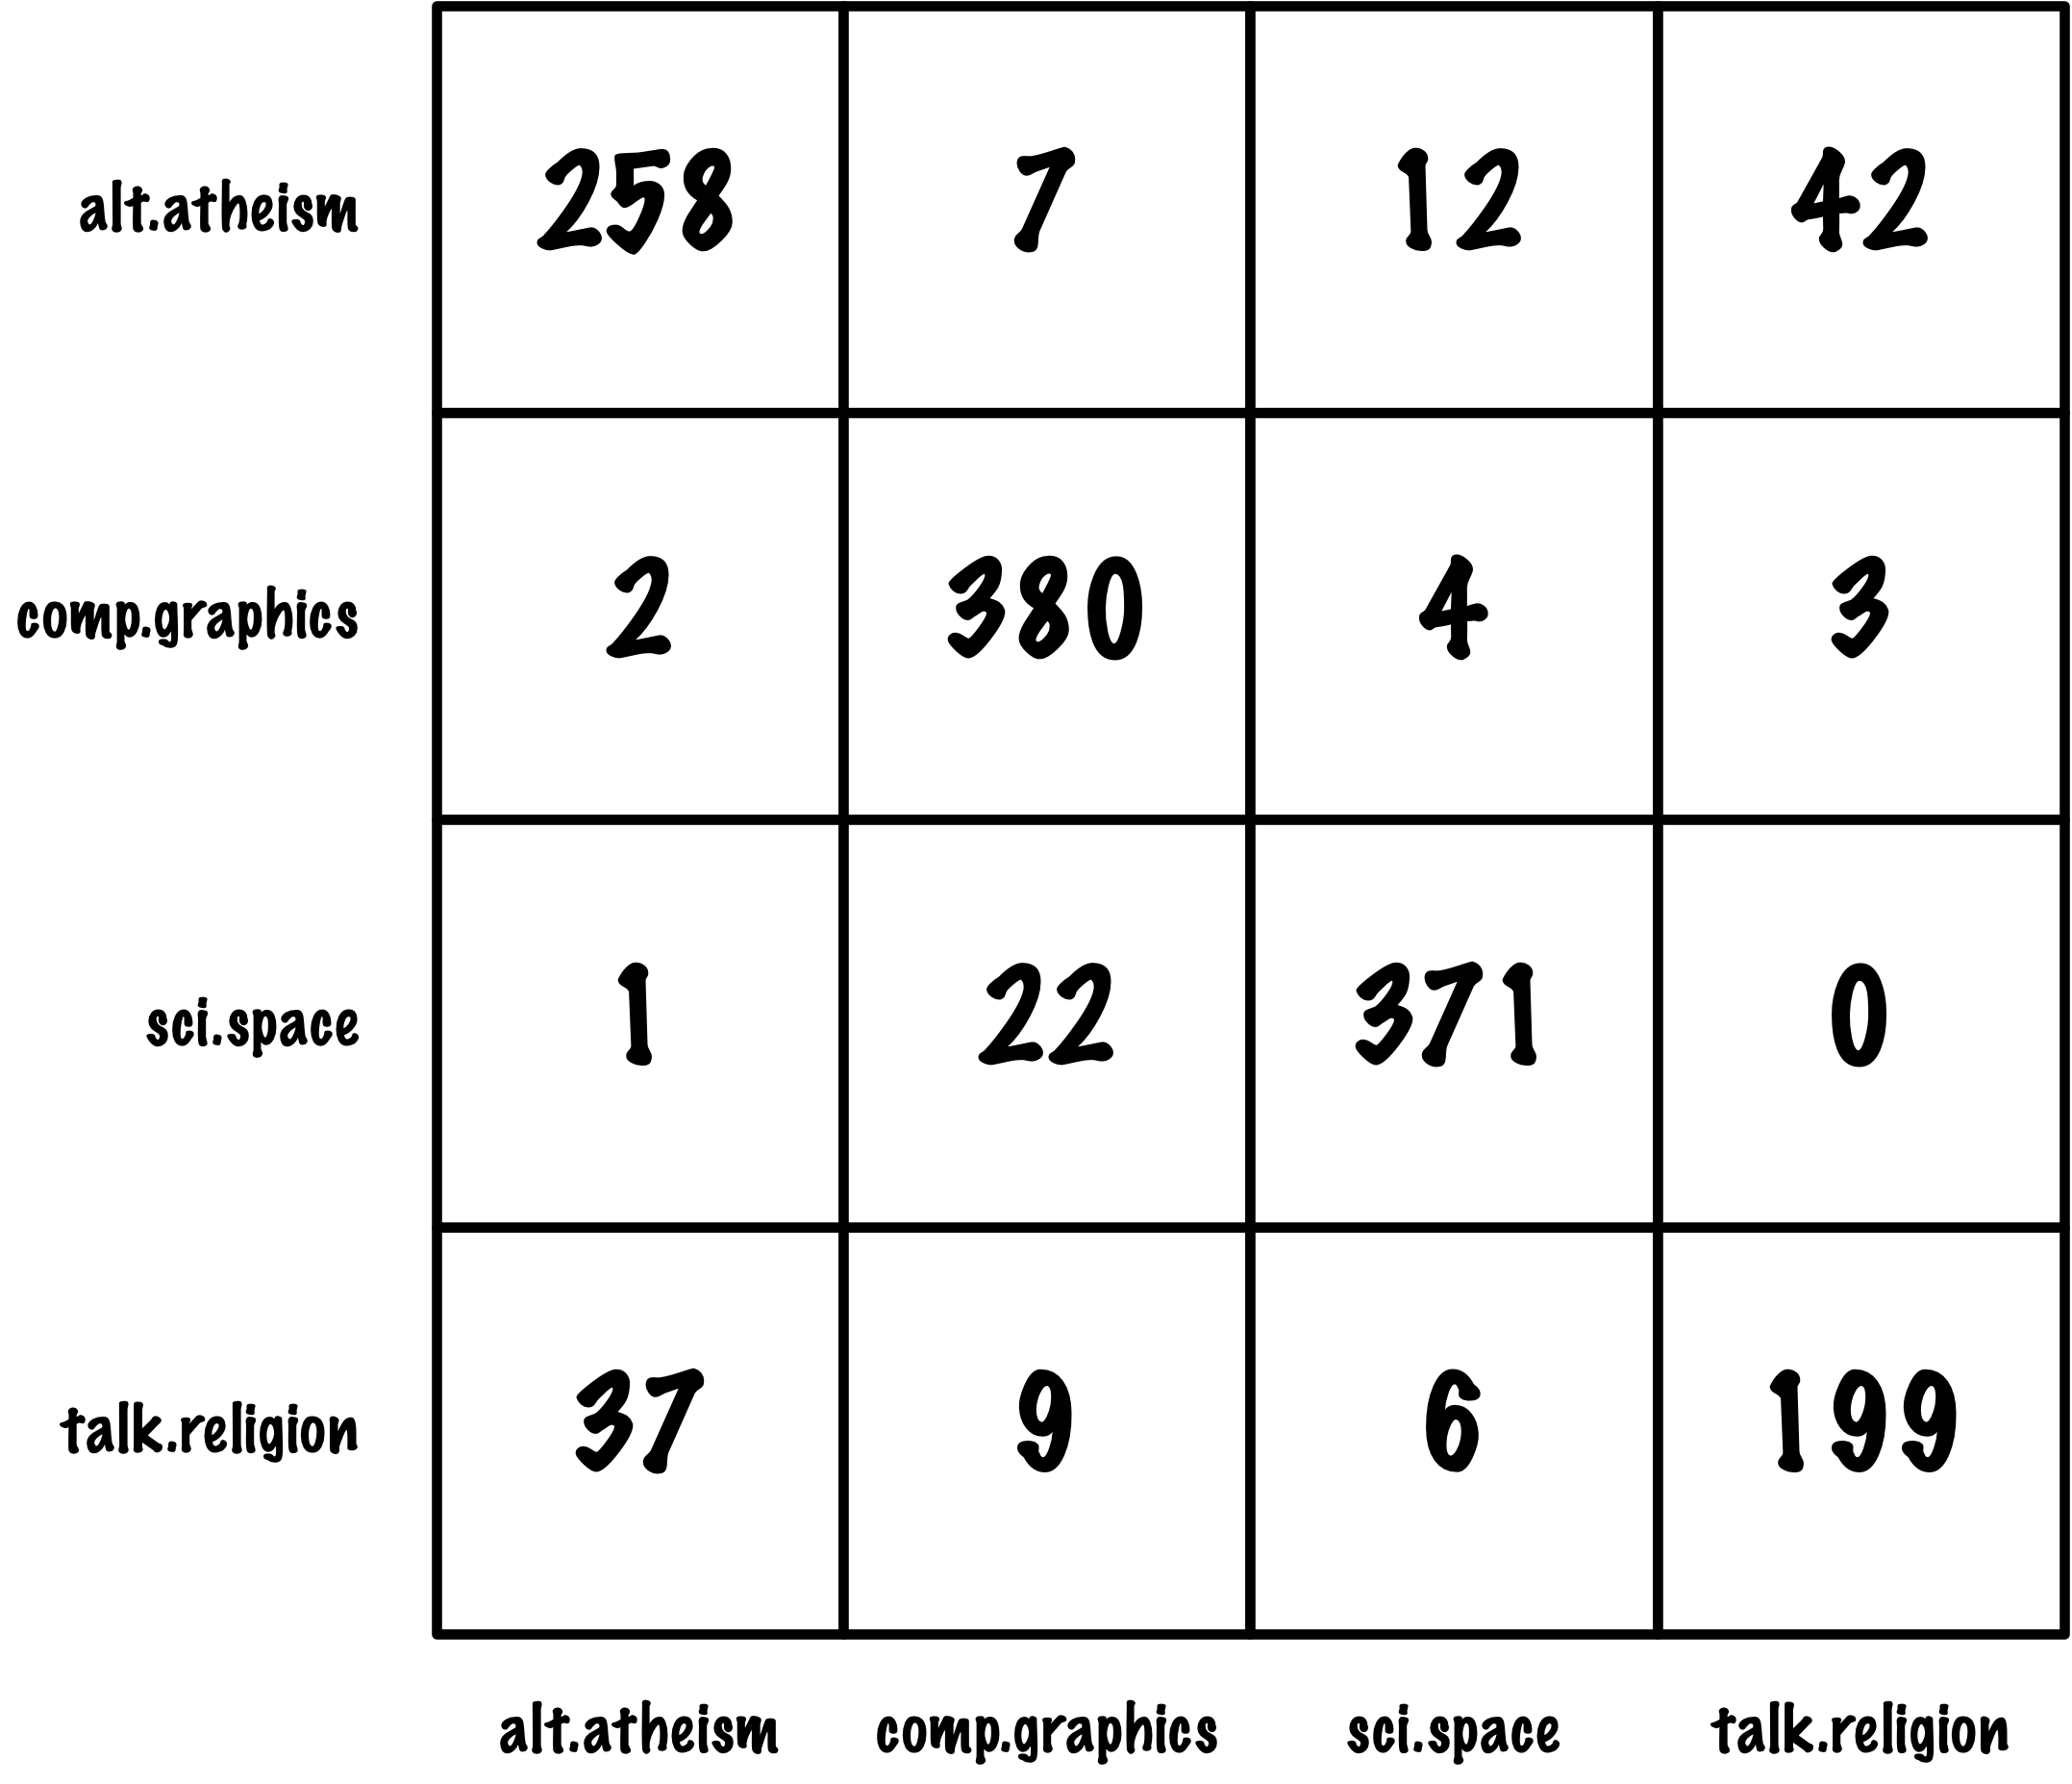

Utilisation des données du [jeu de données textuel 20
newsgroups](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html#sklearn.datasets.fetch_20newsgroups)
de [scikit-learn.org](https://scikit-learn.org).

## Matrice de confusion - vrai positif

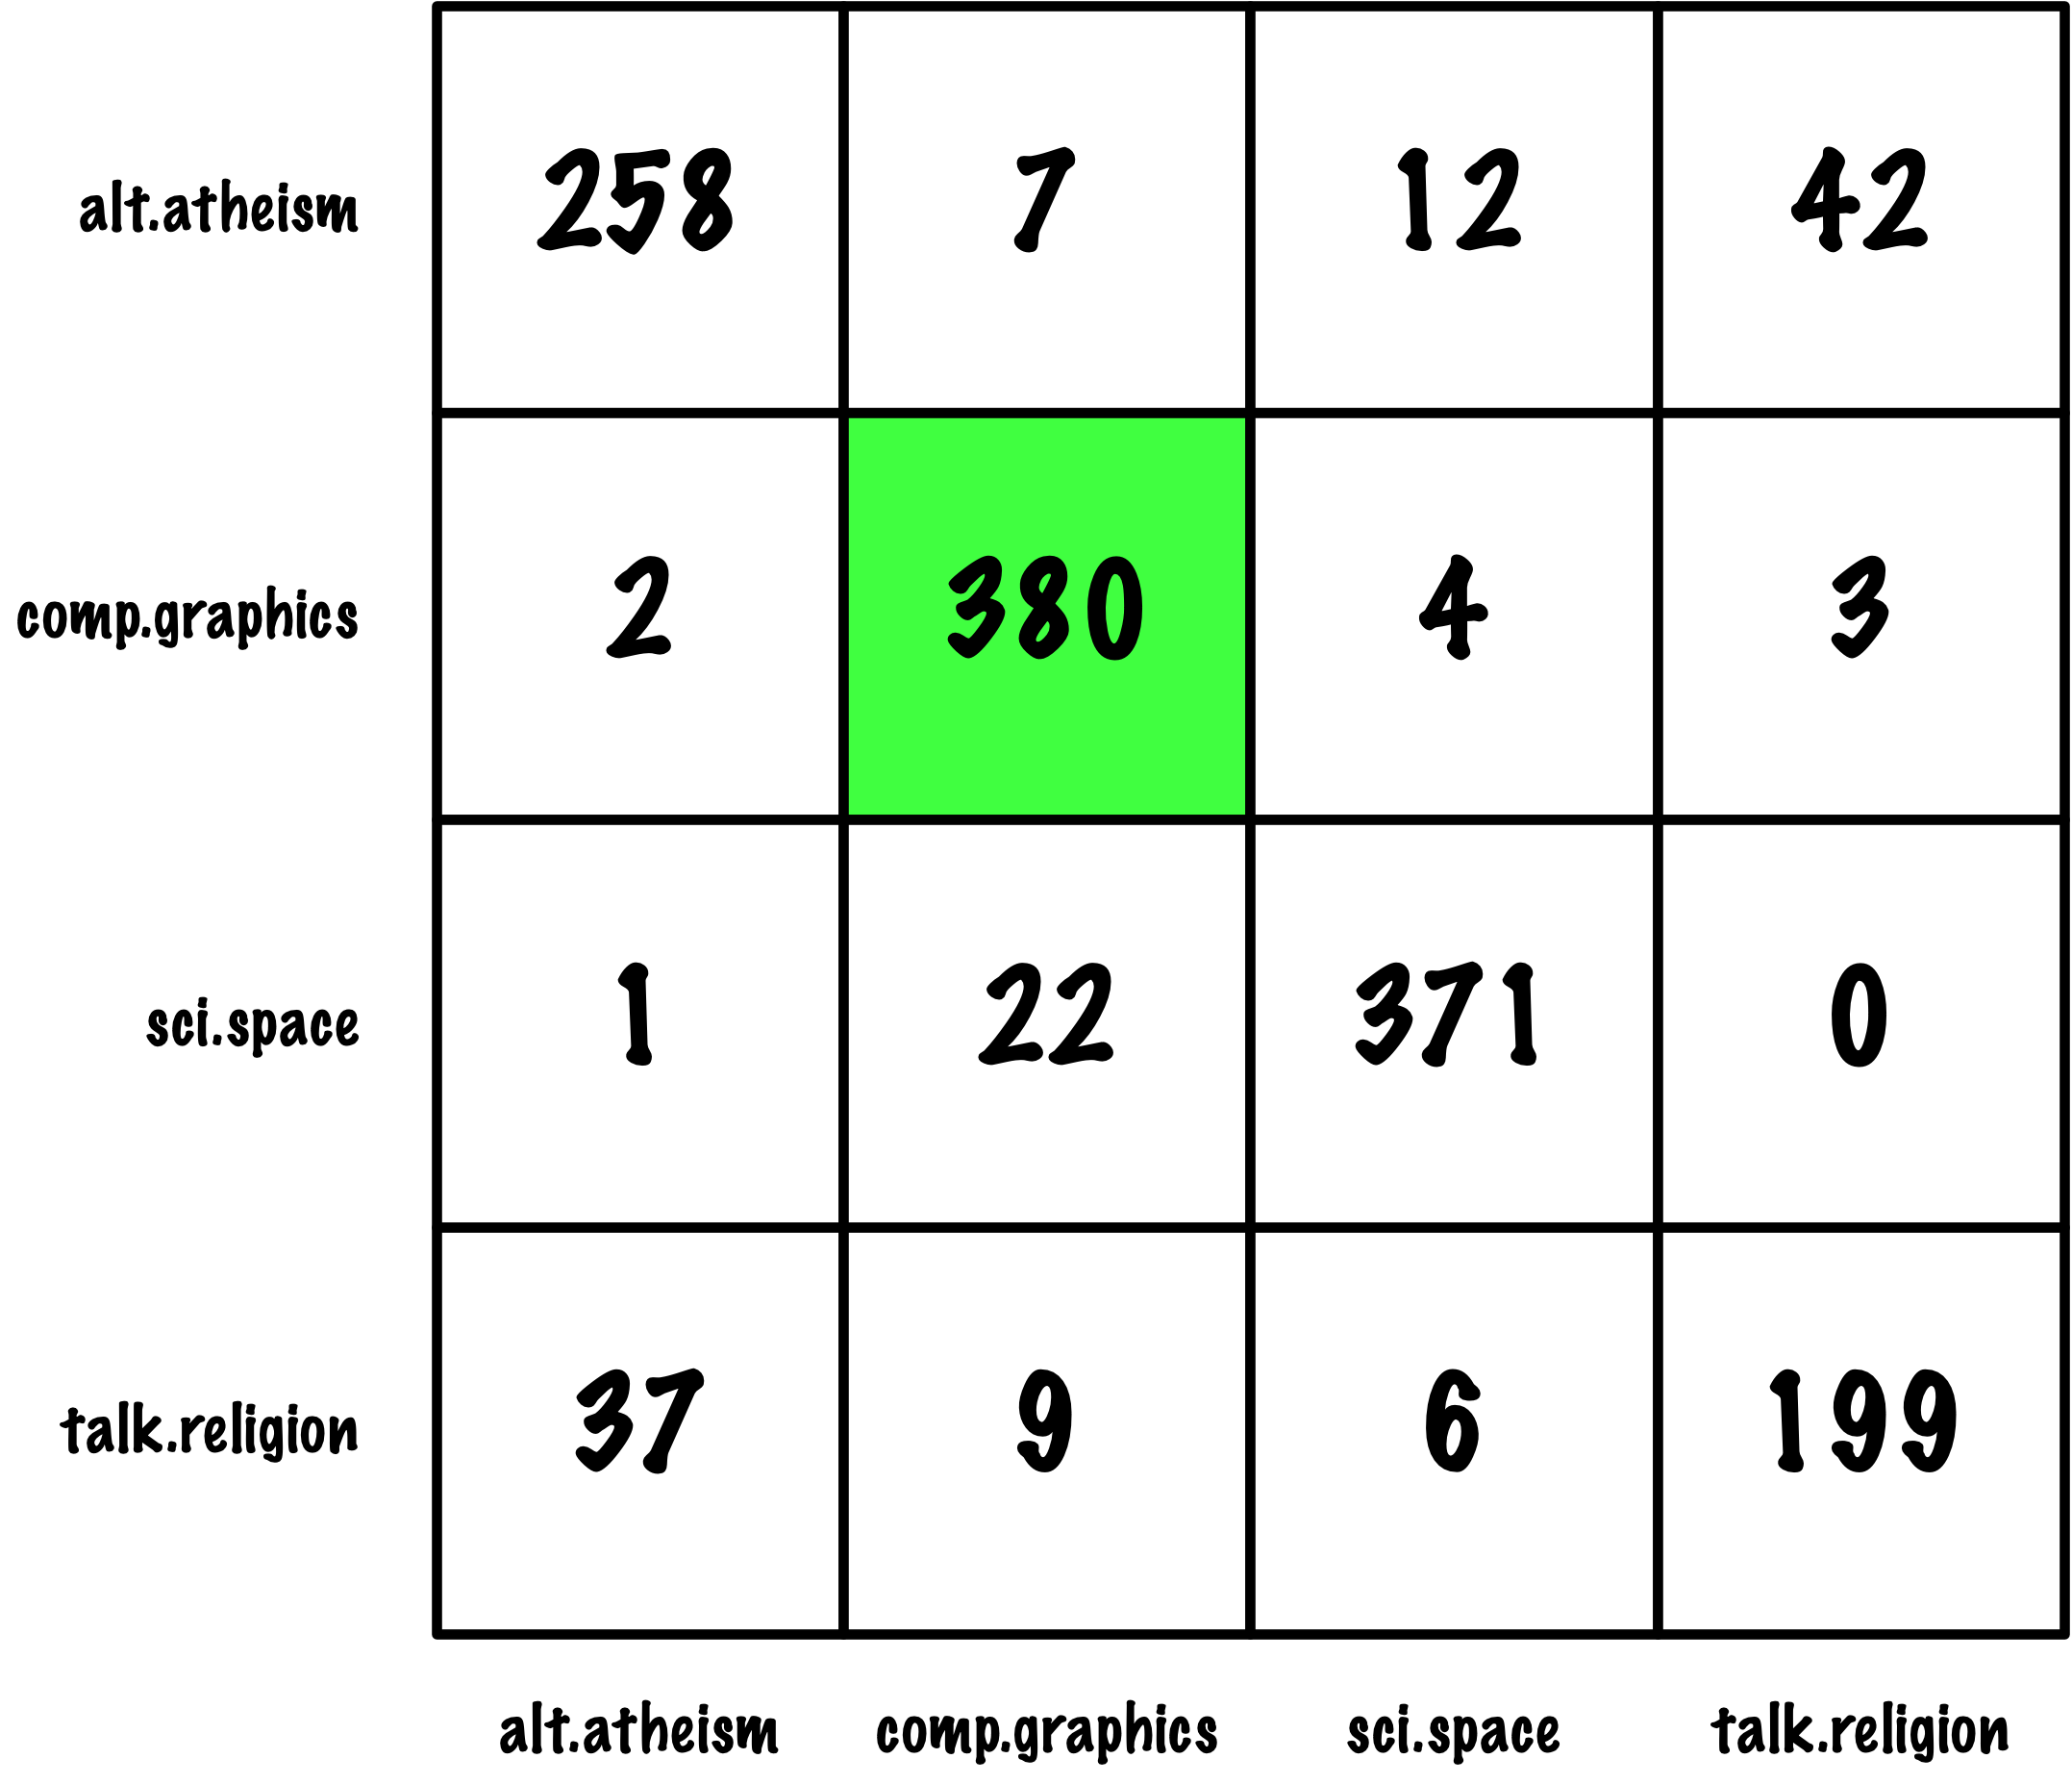

`comp.graphics` est la classe **vraie** ($i$).

## Matrice de confusion - faux positif

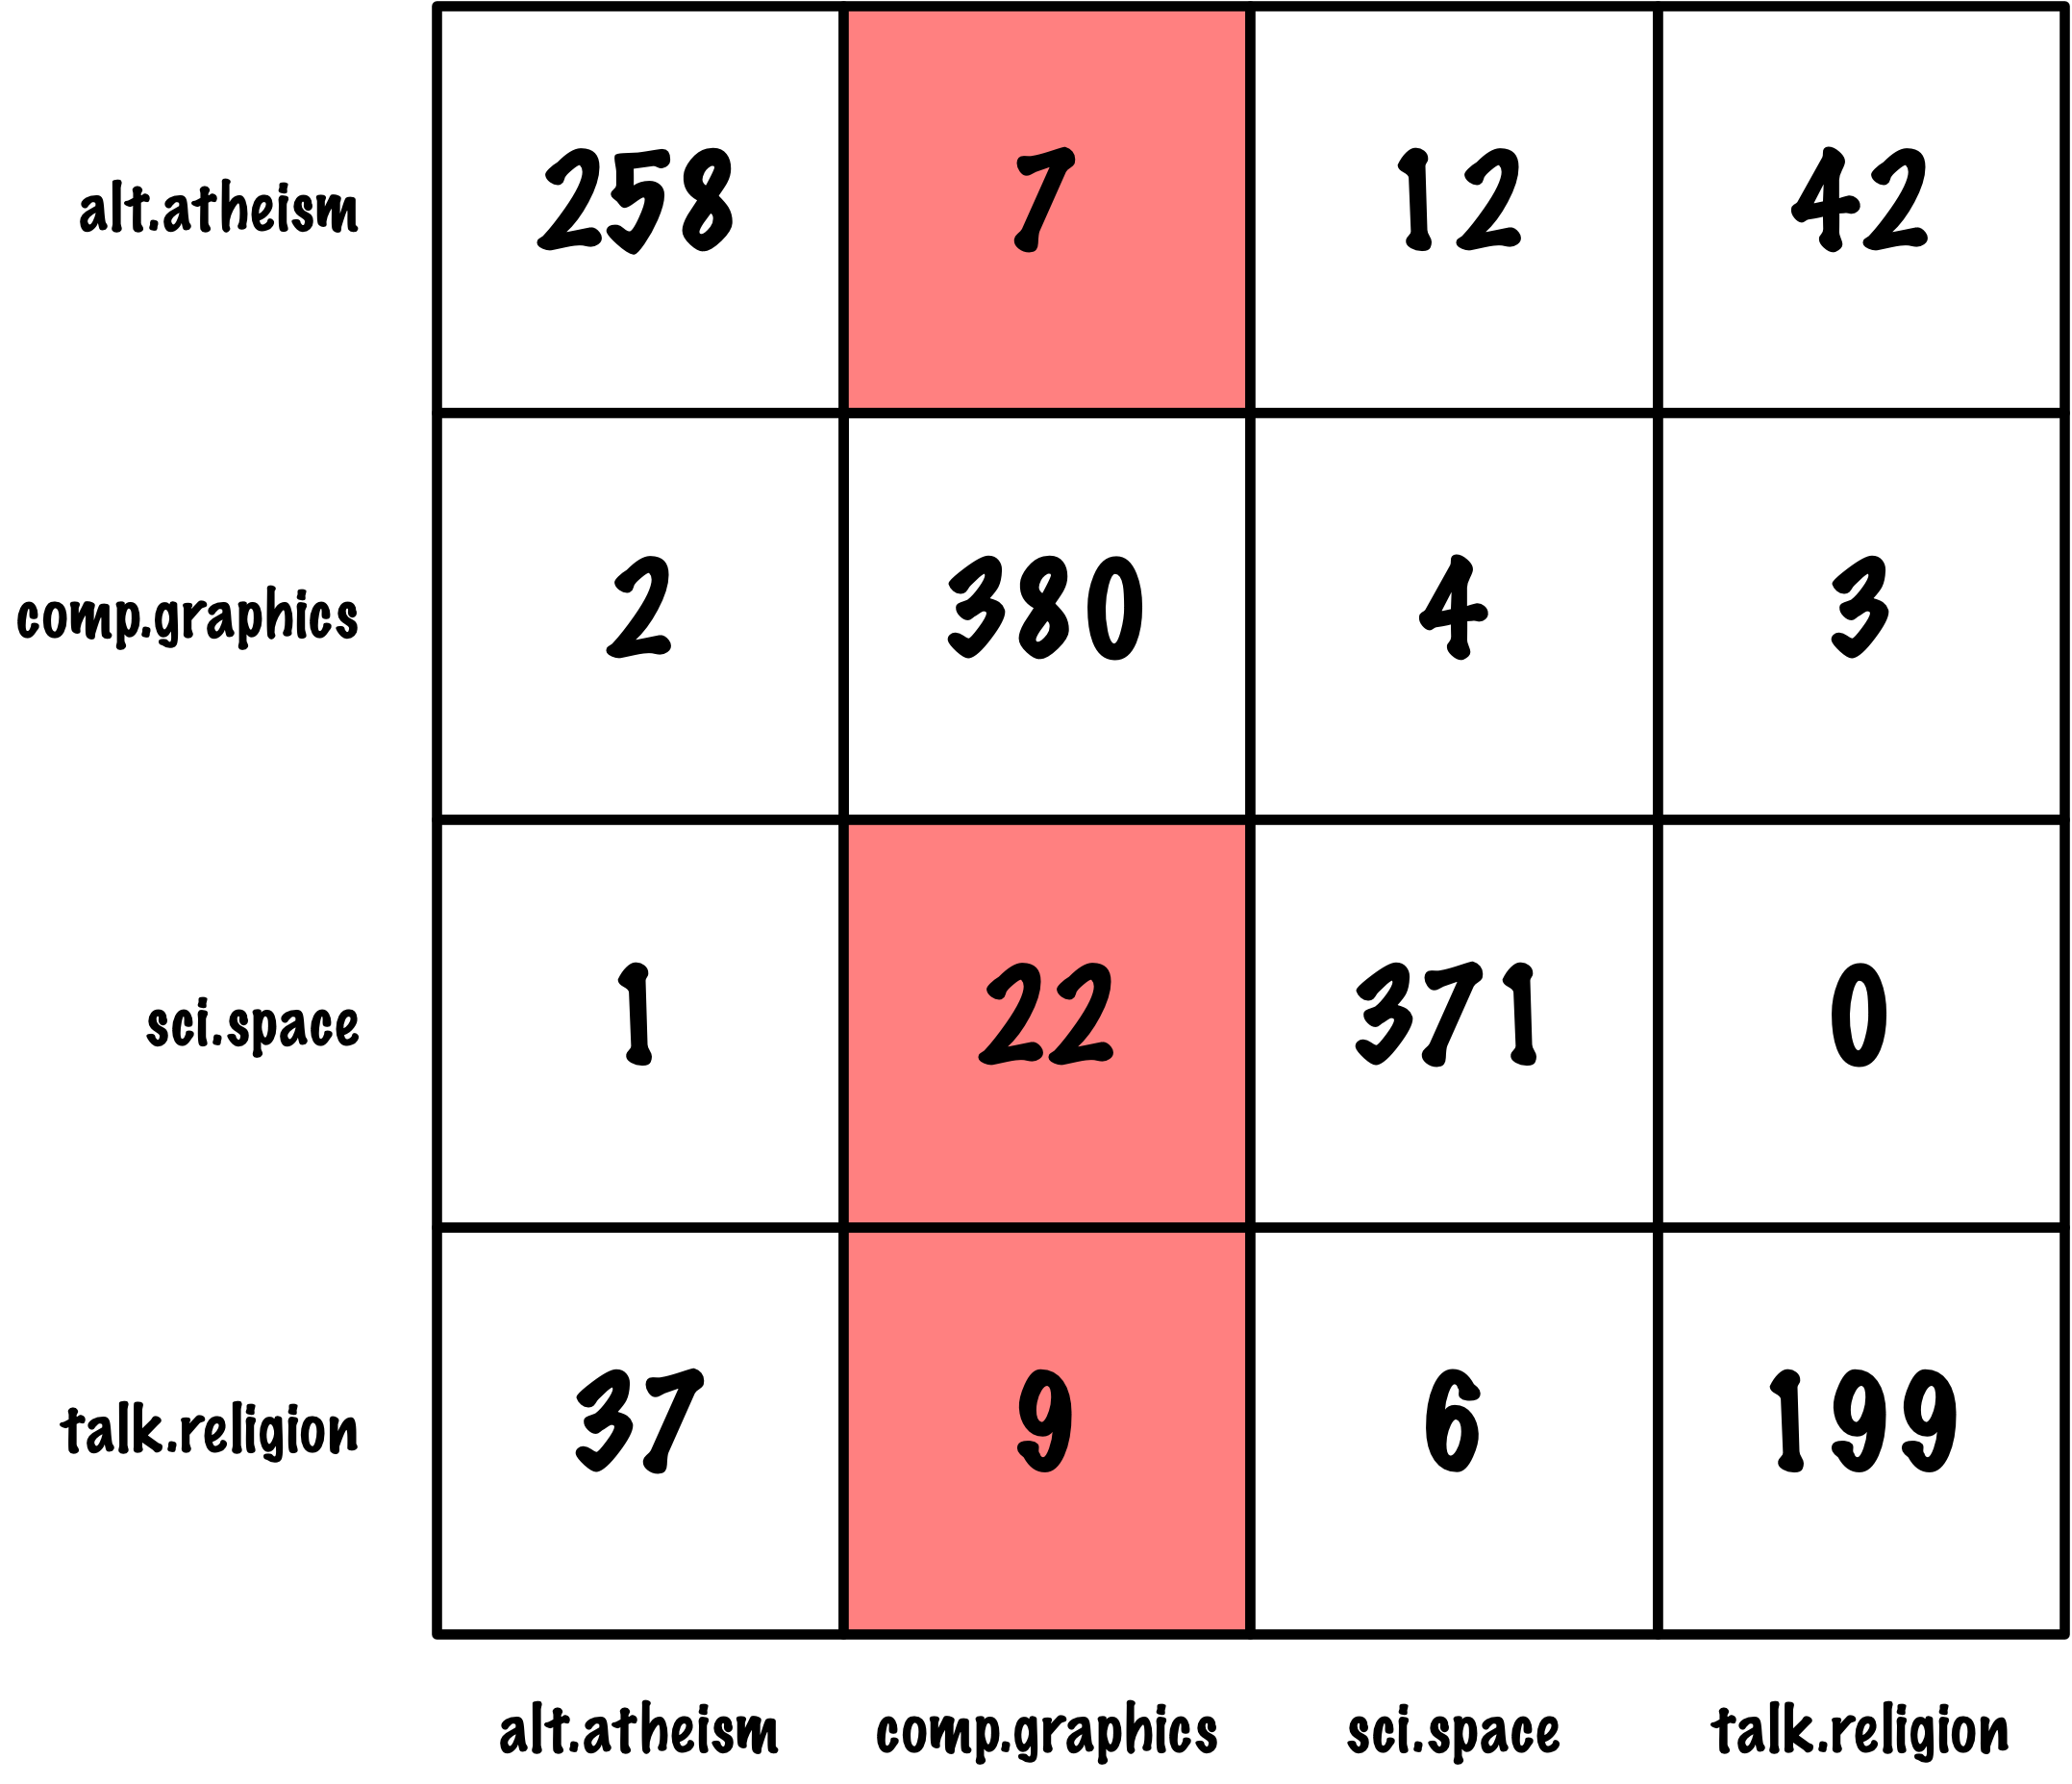

`comp.graphics` est la classe **vraie** ($i$).

## Matrice de confusion - faux négatif

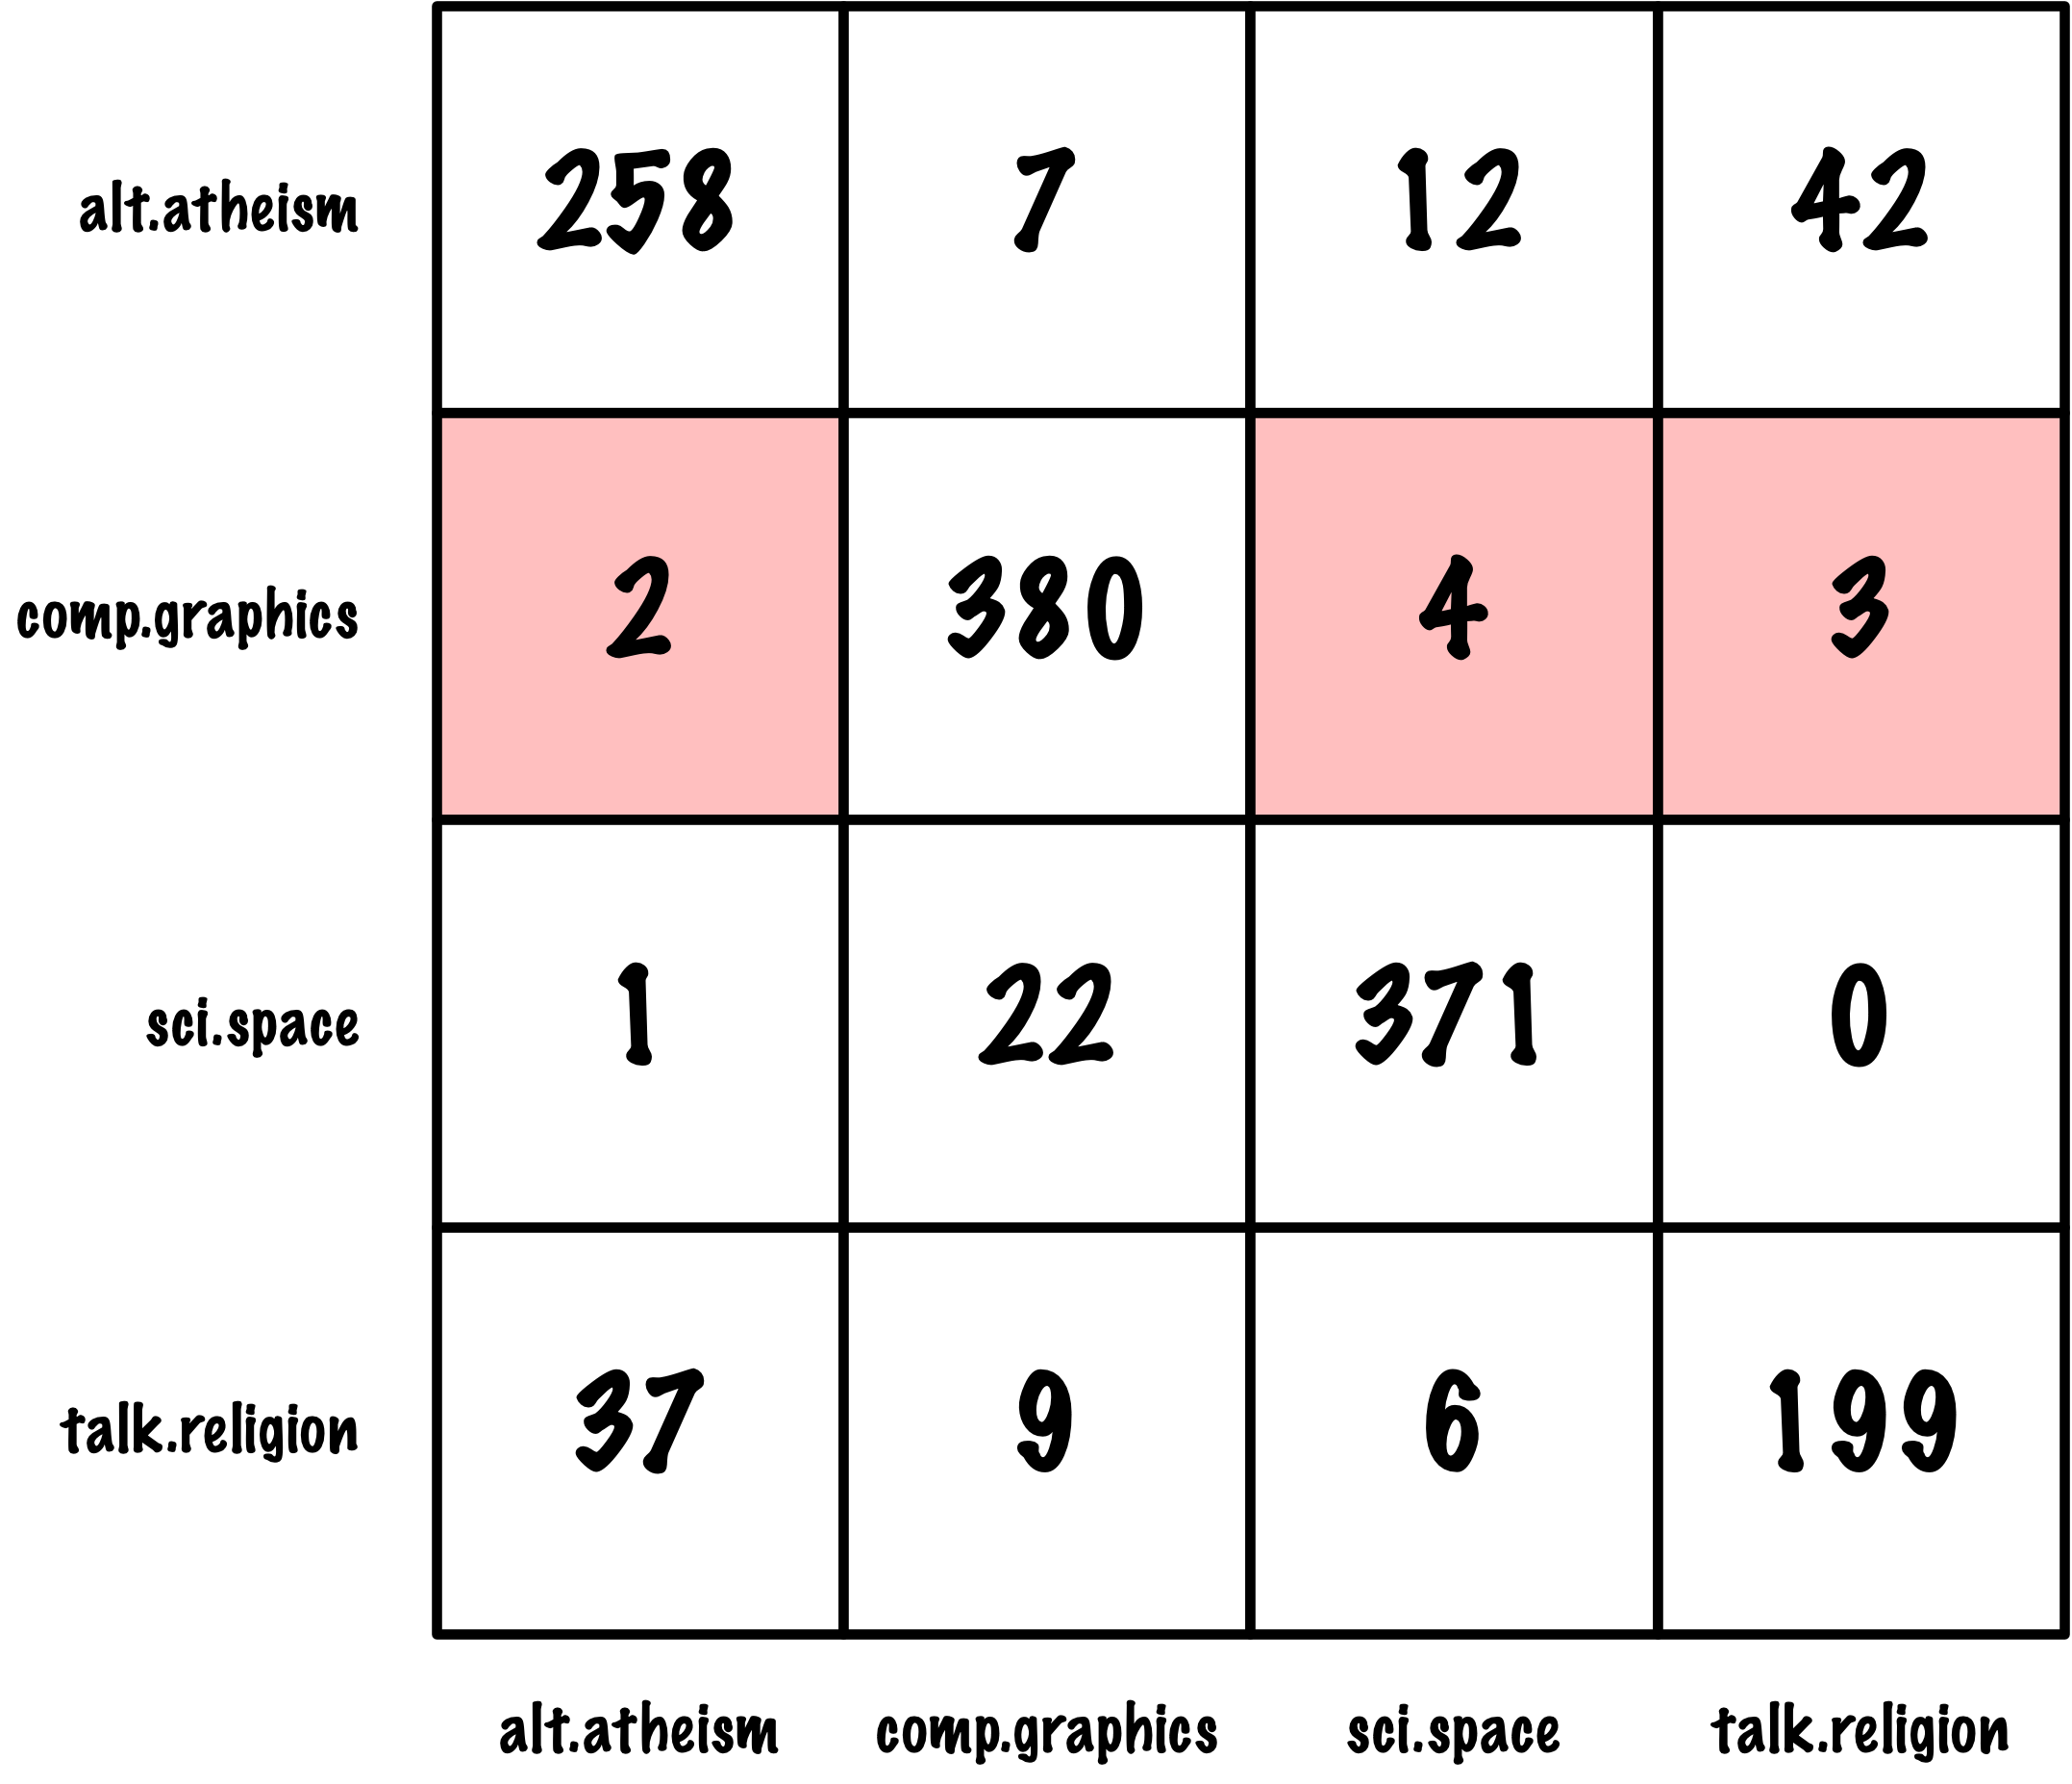

`comp.graphics` est la classe **vraie** ($i$).

## Matrice de confusion - vrai négatif

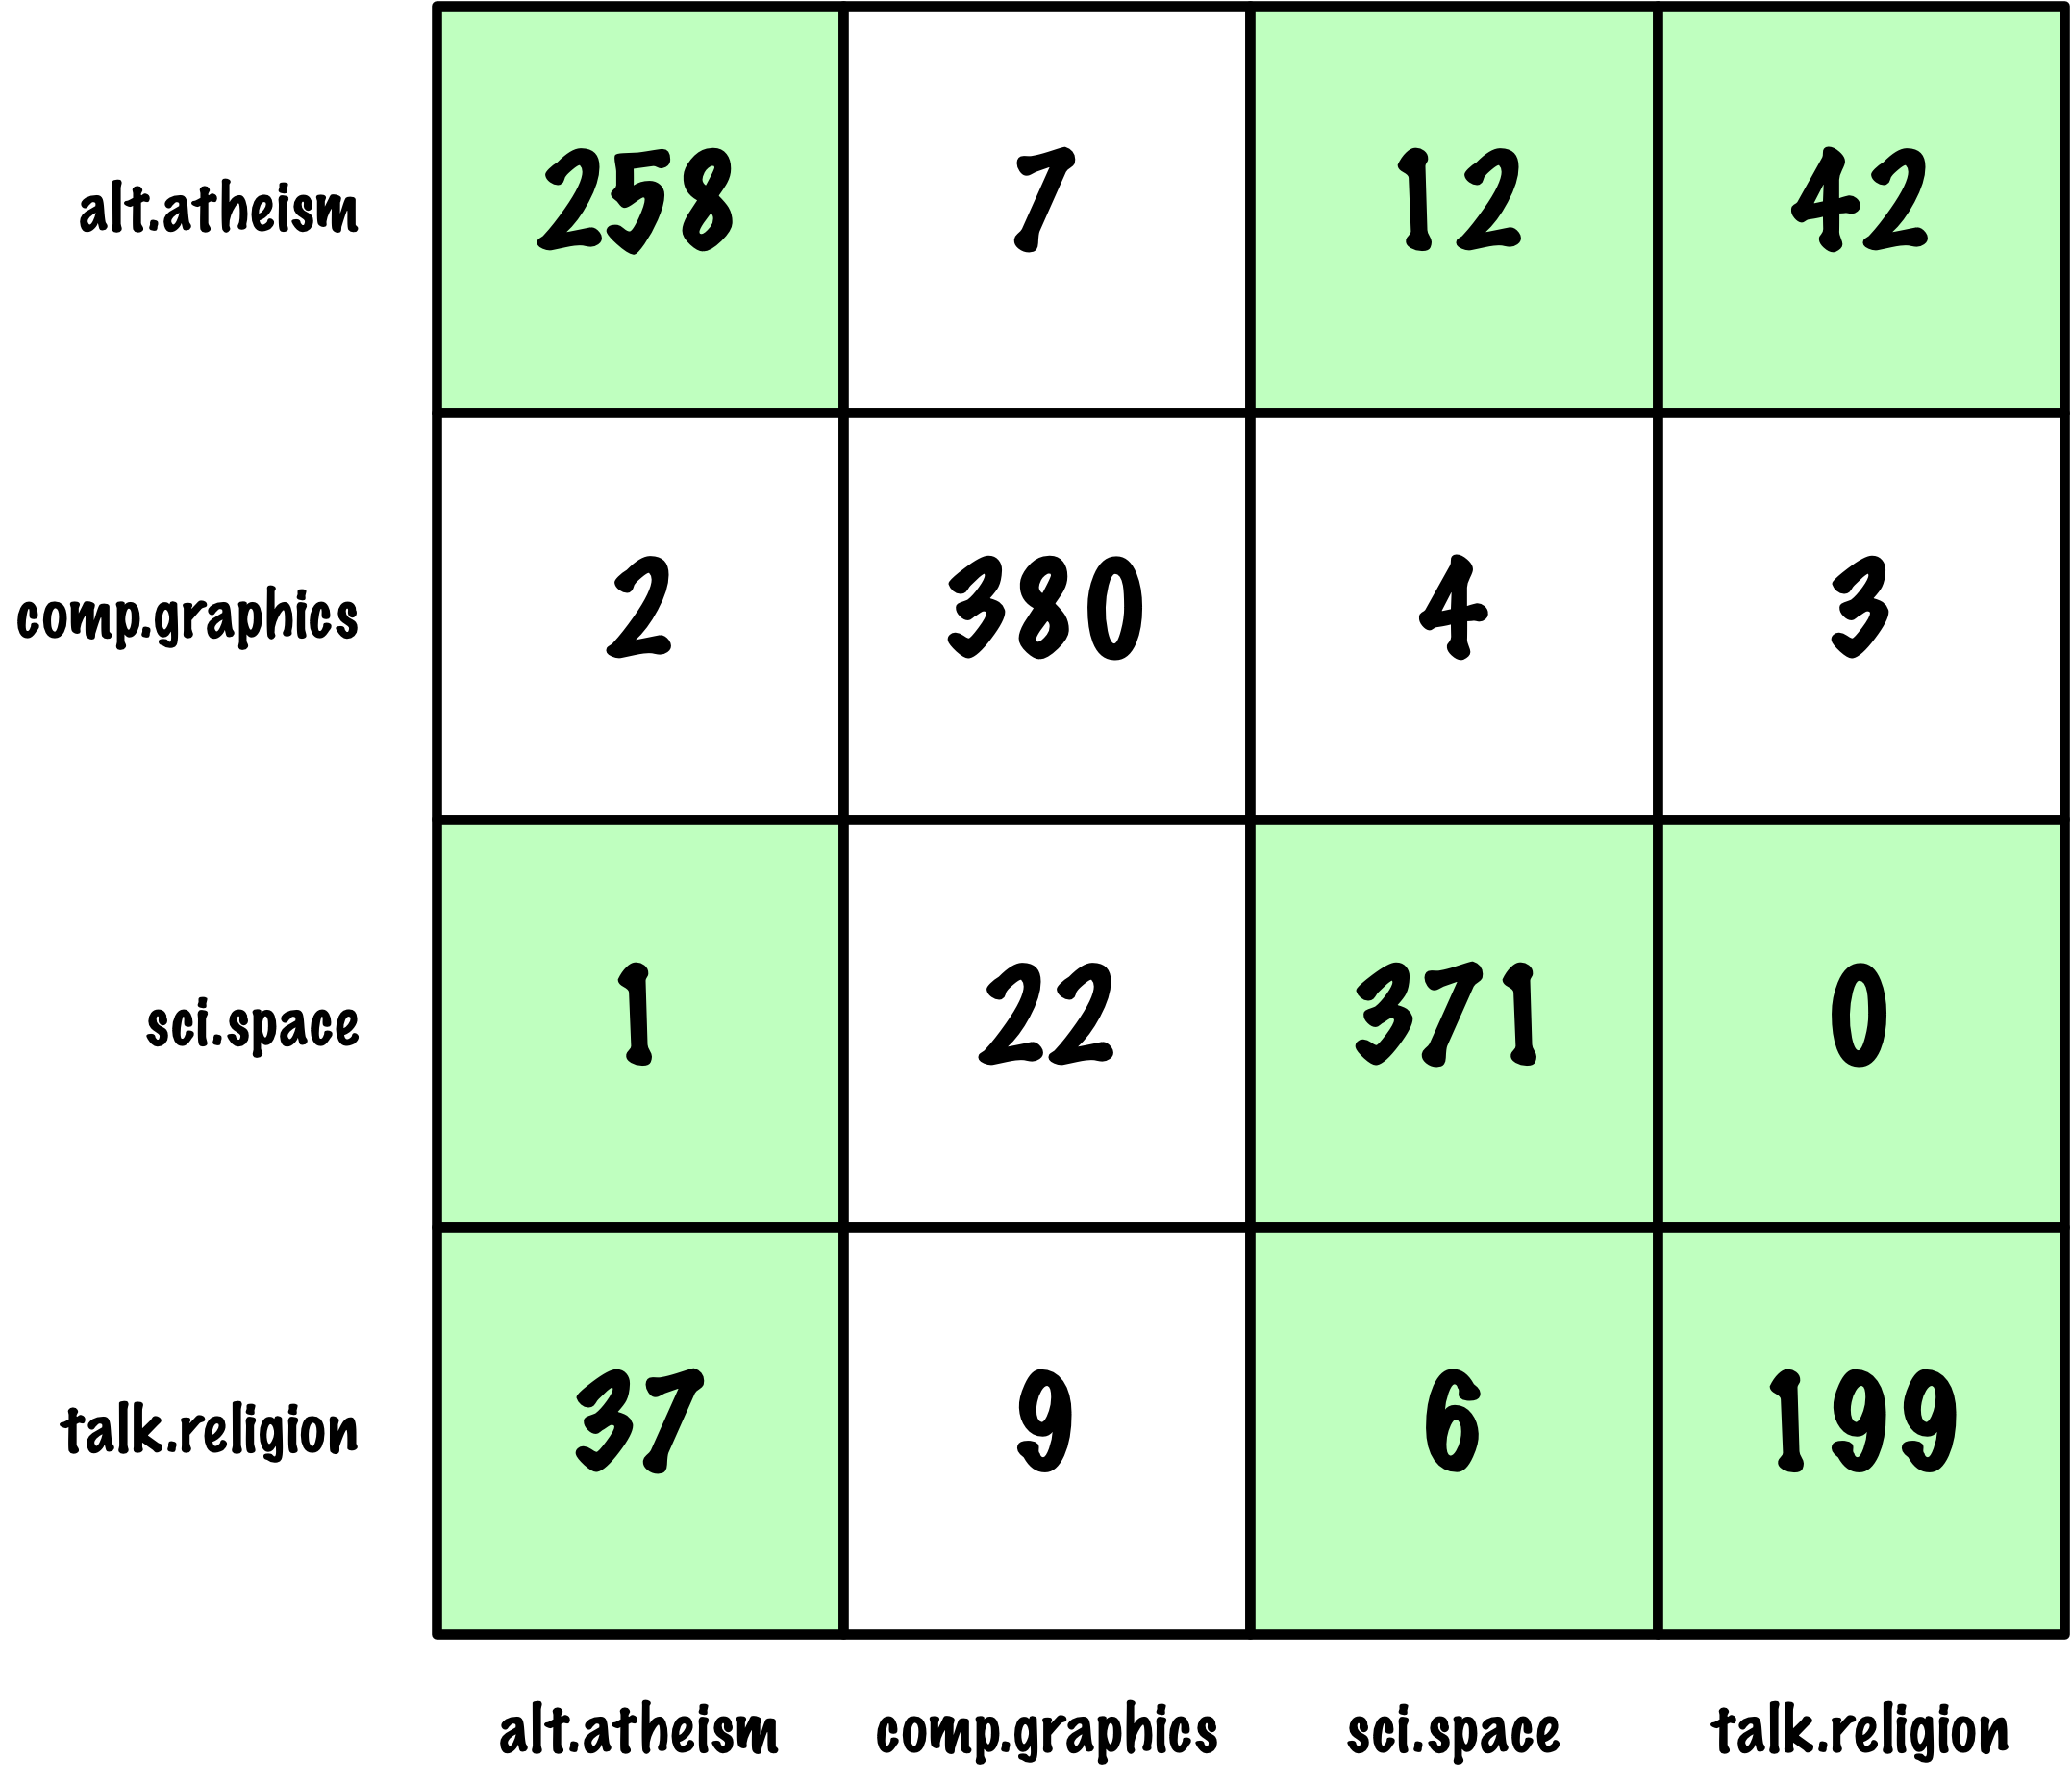

`comp.graphics` est la classe **vraie** ($i$).

## Matrice de confusion - multi-classes

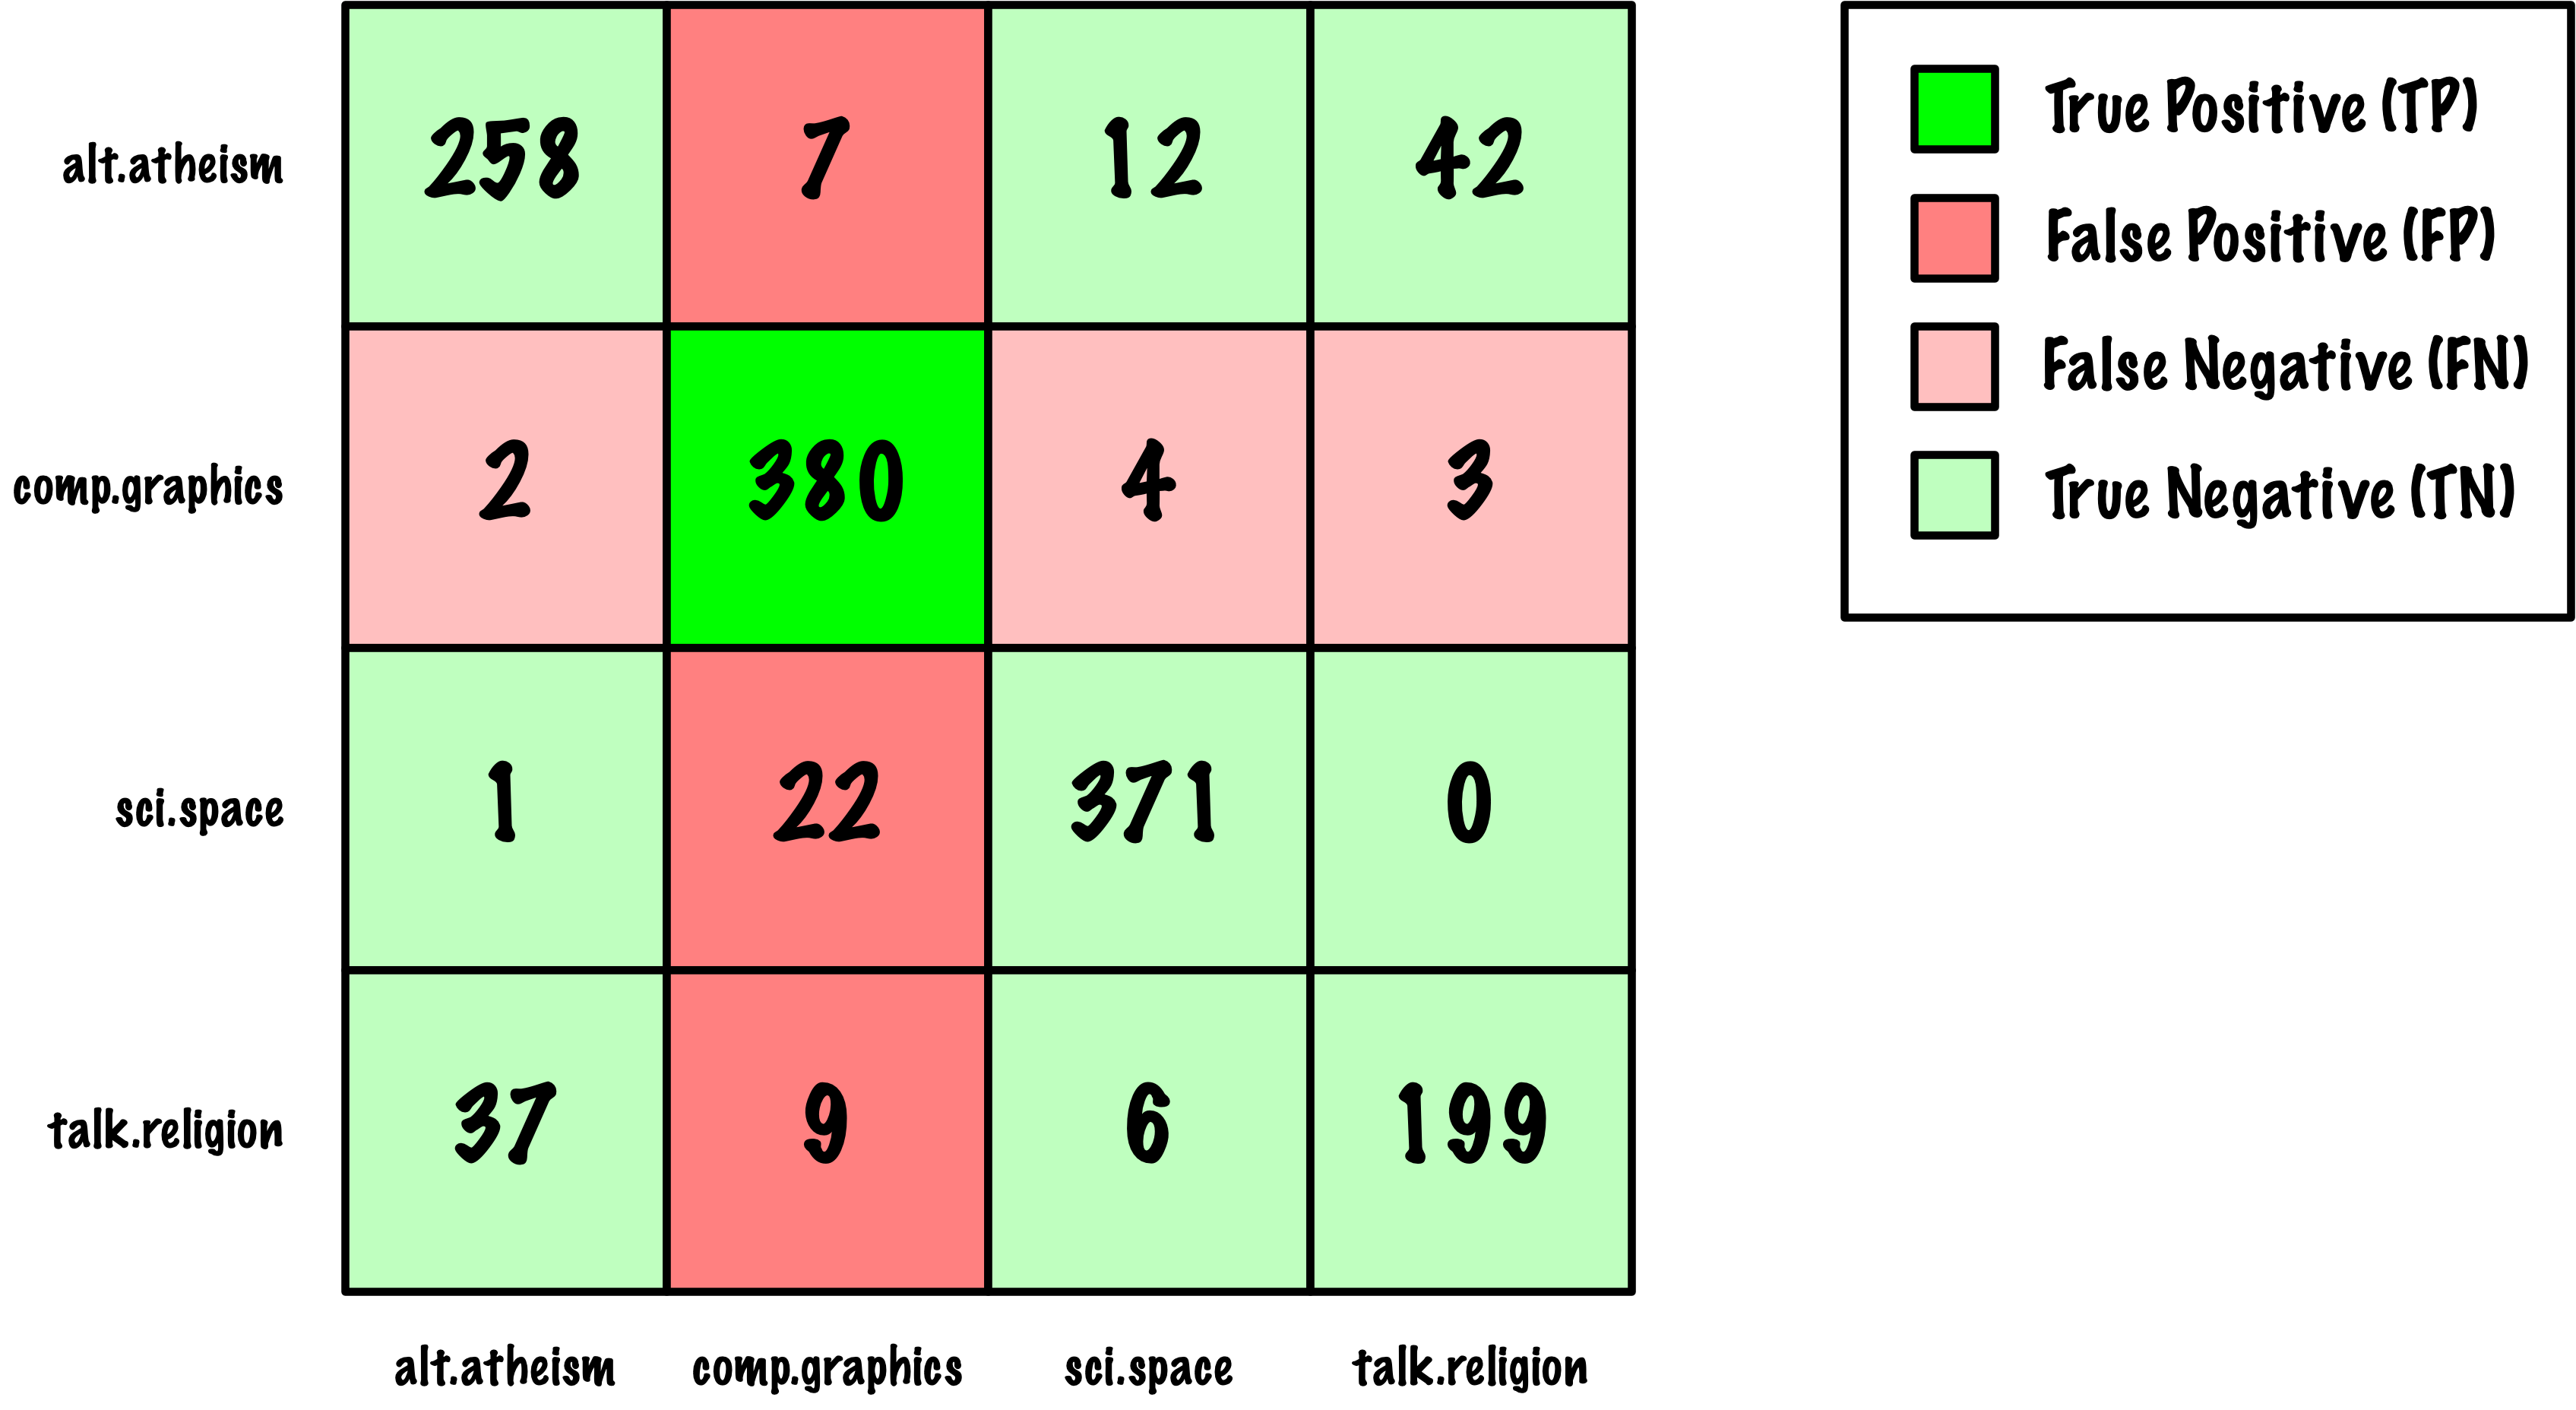

`comp.graphics` est la classe **vraie** ($i$).

## Multi-classes

Pour évaluer la performance dans un contexte multi-classes, on dérive
généralement des métriques “un-contre-tous” pour chaque classe à partir
de la matrice de confusion. Ces métriques sont ensuite moyennées en
utilisant des schémas de pondération spécifiques.

- **Vrais Positifs** ($\mathrm{TP}_i$) : Entrée diagonale $C_{i,i}$
- **Faux Positifs** ($\mathrm{FP}_i$) : Somme de la colonne $i$ excluant
  $C_{i,i}$
- **Faux Négatifs** ($\mathrm{FN}_i$) : Somme de la ligne $i$ excluant
  $C_{i,i}$
- **Vrais Négatifs** ($\mathrm{TN}_i$) :
  $N - (\mathrm{TP}_i + \mathrm{FP}_i + \mathrm{FN}_i)$

## Multi-classes

Pour évaluer la performance dans un contexte multi-classes, on dérive
généralement des métriques “un-contre-tous” pour chaque classe à partir
de la matrice de confusion. Ces métriques sont ensuite moyennées en
utilisant des schémas de pondération spécifiques.

- $\mathrm{TP}_i = C_{i,i}$
- $\mathrm{FP}_i = \sum_{k \ne i} C_{k,i}$
- $\mathrm{FN}_i = \sum_{k \ne i} C_{i,k}$
- $\mathrm{TN}_i = \sum_{j \ne i} \sum_{k \ne i} C_{j,k}$

## sklearn.metrics.confusion_matrix

In [3]:
from sklearn.metrics import confusion_matrix

y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 1, 1, 0, 0, 0, 1, 1, 1, 1]

confusion_matrix(y_actual,y_pred)

array([[1, 2],
       [3, 4]])

. . .

In [4]:
tn, fp, fn, tp = confusion_matrix(y_actual, y_pred).ravel().tolist()
(tn, fp, fn, tp)

(1, 2, 3, 4)

Par défaut, `sklearn.metrics.confusion_matrix` détermine l’ensemble des
étiquettes à partir des données
($\textrm{y_true} \cup \textrm{y_pred}$), et ensuite :

- Il les trie par ordre croissant (ce qui, pour les chaînes ou les types
  mixtes, correspond à l’ordre lexicographique de Python).
- Il construit ensuite la matrice de sorte que la ligne `i` corresponde
  à la classe réelle avec l’étiquette `labels[i]`, et la colonne `j`
  corresponde à la classe prédite avec l’étiquette `labels[j]`.

Donc, si vous ne passez pas `labels=...`, vous pouvez obtenir une
matrice de confusion avec un ordre de classes qui n’est pas celui que
vous attendez — surtout si vos classes sont des chaînes, ou si vous
supposez que l’ordre suit l’ordre d’apparition dans le jeu de données.

**Exemple**

``` python
from sklearn.metrics import confusion_matrix

y_true = ["dog", "cat", "cat", "dog"]
y_pred = ["dog", "dog", "cat", "cat"]

print(confusion_matrix(y_true, y_pred))
```

Résultat :

    [[1 1]
     [1 1]]

Ici, les lignes/colonnes sont dans l’ordre lexicographique :
`["cat", "dog"]`. Donc la matrice est :

- Ligne 0 : vrai = “chat”
- Ligne 1 : vrai = “chien”

**Contrôler l’ordre**

Pour imposer un ordre spécifique, vous devez passer l’argument labels :

``` python
confusion_matrix(y_true, y_pred, labels=["dog", "cat"])
```

Cela permutera l’ordre des lignes/colonnes en conséquence.

## Prédiction parfaite

In [5]:
y_actual = [0, 1, 0, 0, 1, 1, 1, 0, 1, 1]
y_pred   = [0, 1, 0, 0, 1, 1, 1, 0, 1, 1]

confusion_matrix(y_actual,y_pred)

array([[4, 0],
       [0, 6]])

. . .

In [6]:
tn, fp, fn, tp = confusion_matrix(y_actual, y_pred).ravel().tolist()  
(tn, fp, fn, tp)

(4, 0, 0, 6)

Lorsqu’un algorithme fait une classification parfaite, toutes les
valeurs non nulles (0) de la matrice de confusion apparaissent
exclusivement le long de sa diagonale.

Toutes les entrées hors diagonale, qui représentent des erreurs de
classification, seront nulles (0).

## Matrice de confusion

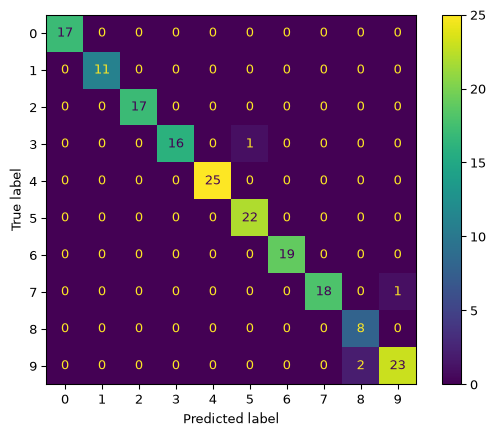

In [7]:
from sklearn.datasets import load_digits

import numpy as np
np.random.seed(42)

digits = load_digits()

X = digits.data
y = digits.target

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

clf = OneVsRestClassifier(LogisticRegression())

clf = clf.fit(X_train, y_train)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

X_test = scaler.transform(X_test)
y_pred = clf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

**Matrice de confusion** pour l’**exemple de chiffres manuscrits**
présenté lors du cours précédent.

L’image affiche une carte thermique de la matrice de confusion pour la
tâche de classification des chiffres. Cette tâche, un problème de
classification multiclasses, a été traitée en utilisant
`OneVsRestClassifier` et `LogisticRegression`.

La matrice de confusion résume les prédictions faites sur l’ensemble de
test, qui est un sous-ensemble des données qui n’a pas été utilisé pour
l’entraînement ni pour le prétraitement avec `StandardScaler`.

La matrice de confusion encapsule tous les résultats de l’application du
classificateur sur l’ensemble de test. Cependant, pour résumer ces
informations plus succinctement, nous nous référons souvent à des
métriques de performance.

## Visualisation des erreurs

In [8]:
mask = (y_test == 9) & (y_pred == 8)

X_9_as_8 = X_test[mask]

y_9_as_8 = y_test[mask]

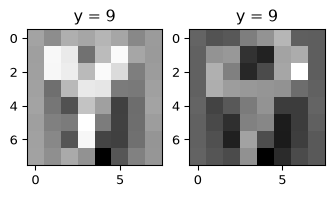

In [9]:
import numpy as np
np.random.seed(42)

from sklearn.datasets import load_digits
digits = load_digits()

X = digits.data
y = digits.target

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

clf = OneVsRestClassifier(LogisticRegression())

clf = clf.fit(X_train, y_train)

X_test = scaler.transform(X_test)
y_pred = clf.predict(X_test)

mask = (y_test == 9) & (y_pred == 8)

X_9_as_8 = X_test[mask]

y_9_as_8 = y_test[mask]

import matplotlib.pyplot as plt

plt.figure(figsize=(4,2))

for index, (image, label) in enumerate(zip(X_9_as_8, y_9_as_8)):
    plt.subplot(1, len(X_9_as_8), index + 1)
    plt.imshow(np.reshape(image, (8,8)), cmap=plt.cm.gray)
    plt.title(f'y = {label}')

Dans la matrice de confusion à l’écran précédent, nous avions vu qu’il y
avait des exemples pour lesquels l’étiquette réelle était 9, mais la
prédiction était 8. Nous pouvons visualiser les exemples pour voir si
nous comprenons la nature de ces erreurs.

## Matrice de confusion

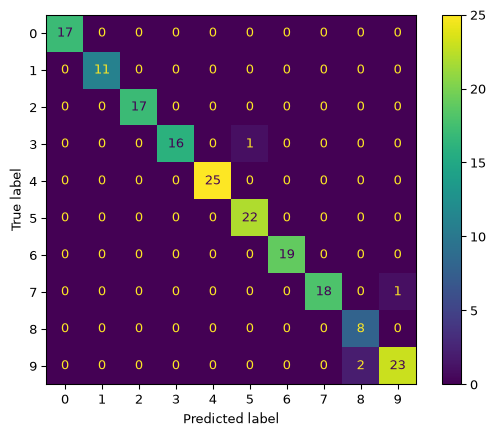

Il est souvent préférable de résumer la performance du classificateur
par une seule métrique.

## Exactitude

Quelle est l’**exactitude** de ce résultat ?

$$
  \mathrm{exactitude} = \frac{\mathrm{VP}+\mathrm{VN}}{\mathrm{VP}+\mathrm{VN}+\mathrm{FP}+\mathrm{FN}} = \frac{\mathrm{VP}+\mathrm{VN}}{\mathrm{N}}
$$

In [11]:
from sklearn.metrics import accuracy_score

y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 1, 1, 0, 0, 0, 1, 1, 1, 1]

accuracy_score(y_actual,y_pred)

0.5

L’**exactitude** est le rapport entre les instances correctement
prédites et le nombre total de prédictions.

Dans le contexte francophone, le terme « accuracy » se traduit
généralement par « exactitude ». Il est important de noter que certaines
applications utilisent à tort le terme « précision » pour désigner
« accuracy ». Or, « précision » correspond en réalité au terme anglais
« precision », qui possède une signification distincte.

## Exactitude

In [12]:
y_actual = [0, 1, 0, 0, 1, 1, 1, 0, 1, 1]
y_pred   = [1, 0, 1, 1, 0, 0, 0, 1, 0, 0]

accuracy_score(y_actual,y_pred)

0.0

In [13]:
y_actual = [0, 1, 0, 0, 1, 1, 1, 0, 1, 1]
y_pred   = [0, 1, 0, 0, 1, 1, 1, 0, 1, 1]

accuracy_score(y_actual,y_pred)

1.0

L’**exactitude** est un nombre entre 0 (tout faux) et 1 (parfait).

## L’exactitude peut être trompeuse

In [14]:
y_actual = [0, 0, 0, 0, 1, 1, 0, 0, 0, 0]
y_pred   = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

accuracy_score(y_actual,y_pred)

0.8

**Pourquoi** est-ce problématique ?

L’exactitude peut être trompeuse dans le contexte du **déséquilibre de
classe**, car elle reflète de manière disproportionnée la performance
sur la classe majoritaire, masquant ainsi une mauvaise performance sur
la classe minoritaire.

À mesure que le **déséquilibre de classe augmente**, la mesure
d’exactitude devient **de plus en plus trompeuse**.

## Précision

Aussi connu sous le nom de **valeur prédictive positive** (PPV).

$$
  \mathrm{précision} = \frac{\mathrm{VP}}{\mathrm{VP}+\mathrm{FP}}
$$

In [15]:
from sklearn.metrics import precision_score

y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 1, 1, 0, 0, 0, 1, 1, 1, 1]

precision_score(y_actual, y_pred)

0.6666666666666666

La **précision** est la proportion de **prédictions positives vraies**
parmi **toutes les prédictions positives**.

Pouvez-vous penser à un problème ou une situation où la précision est
primordiale ?

Un exemple classique : **le dépistage médical pour une maladie rare mais
grave**.

- Supposons que vous avez un test pour une maladie avec une prévalence
  très faible (disons 1 sur 10 000).
- Si votre modèle prédit “positif” trop vaguement, vous générerez de
  nombreux faux positifs.
- Ici, la précision (la proportion des positifs prédits qui sont
  réellement des vrais positifs) est cruciale :

$$
\text{Précision} = \frac{\text{VP}}{\text{VP} + \text{FP}}
$$

- Une haute précision signifie que lorsque le test dit “positif”, il est
  très probablement correct.
- Cela réduit l’anxiété inutile, les coûts et les procédures de suivi
  pour les patients incorrectement signalés.

Autres contextes réels où la précision est essentielle :

- Détection de spam : Une haute précision garantit que les e-mails
  classés comme spam le sont vraiment (minimisant les faux positifs qui
  cacheraient de vrais e-mails).
- Recherche de documents juridiques / e-discovery : Une haute précision
  garantit que les documents renvoyés sont pertinents, réduisant le
  temps perdu sur des résultats non pertinents.
- Systèmes de recommandation : Une haute précision signifie que les
  articles recommandés sont très susceptibles d’être intéressants,
  améliorant la confiance des utilisateurs.

## La précision seule ne suffit pas

In [16]:
y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]

precision_score(y_actual,y_pred)

1.0

Un algorithme qui fait un petit nombre de prédictions à haute confiance
pourrait atteindre un score de précision élevé, mais cela ne sera pas
nécessairement utile.

## Rappel

Aussi connu sous le nom de **sensibilité** ou **taux de vrais positifs**
(TPR)

$$
  \mathrm{rappel} = \frac{\mathrm{VP}}{\mathrm{VP}+\mathrm{FN}}
$$

In [17]:
from sklearn.metrics import recall_score

y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 1, 1, 0, 0, 0, 1, 1, 1, 1]

recall_score(y_actual,y_pred)

0.5714285714285714

**Rappel** est la proportion d’instances positives correctes identifiées
parmi toutes les instances réellement positives.

Pouvez-vous penser à un problème ou une situation où le rappel est
primordial ?

Un exemple où le rappel est la mesure critique : **diagnostic du cancer
(dépistage des tumeurs malignes)**.

- Ici, les faux négatifs (manquer un cas réel de cancer) sont beaucoup
  plus dangereux que les faux positifs.
- Le rappel mesure la proportion de vrais positifs correctement
  identifiés :

$$
\text{Rappel} = \frac{\text{VP}}{\text{VP} + \text{FN}}
$$

- Un rappel élevé signifie que le test détecte presque tous les patients
  atteints de cancer, même s’il génère également quelques fausses
  alertes.
- Manquer un cas réel (rappel faible) pourrait signifier qu’un patient
  ne reçoit pas de traitement à temps — une erreur beaucoup plus grave
  que d’investiguer quelques faux positifs supplémentaires.

Autres contextes réels où le rappel est le plus important :

- Sécurité / Détection d’intrusions : Mieux vaut signaler toute activité
  suspecte (même avec des faux positifs) que de manquer une véritable
  attaque.
- Moteurs de recherche : Pour certaines requêtes (par exemple, recherche
  de précédents juridiques, recherche de littérature médicale), le
  rappel garantit que vous récupérez tous les documents pertinents.
- Systèmes de réponse d’urgence : Pour les alertes de catastrophes
  naturelles, un rappel élevé garantit qu’aucune menace réelle ne passe
  inaperçue.

## Score F$_1$

$$
\begin{align*}
  F_1~\mathrm{score} &= \frac{2}{\frac{1}{\mathrm{précision}}+\frac{1}{\mathrm{rappel}}} = 2 \times \frac{\mathrm{précision}\times\mathrm{rappel}}{\mathrm{précision}+\mathrm{rappel}} \\
                     &= \frac{\mathrm{VP}}{\mathrm{VP}+\frac{\mathrm{FN}+\mathrm{FP}}{2}}
\end{align*}
$$

In [18]:
from sklearn.metrics import f1_score

y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 1, 1, 0, 0, 0, 1, 1, 1, 1]

f1_score(y_actual,y_pred)

0.6153846153846154

**F$_1$** est la **moyenne harmonique** de la précision et du rappel.

- La moyenne harmonique met davantage l’accent sur les valeurs plus
  faibles, tandis que la moyenne arithmétique traite toutes les valeurs
  de manière égale.
- Utiliser la moyenne harmonique garantit qu’un score élevé n’est obtenu
  que lorsque la précision et le rappel sont tous deux élevés, offrant
  ainsi une mesure plus holistique des performances d’un classificateur
  dans des scénarios avec des ensembles de données déséquilibrés.
- Le score F$_1$ favorise les classificateurs qui réalisent un équilibre
  entre la précision et le rappel.
- Augmenter le **rappel** entraîne souvent une diminution de la
  **précision**, et vice versa. Ce phénomène est connu sous le nom de
  **compromis précision/rappel**.

# Moyennes micro et macro

## Définition

Le **problème de déséquilibre de classes** est un scénario où le nombre
d’instances dans une classe dépasse significativement le nombre
d’instances dans d’autres classes.

. . .

Les modèles ont tendance à être biaisés en faveur de la **classe
majoritaire**, ce qui conduit à **une mauvaise performance sur la classe
minoritaire**.

Les mesures d’évaluation standard comme la précision peuvent être
trompeuses en présence d’un déséquilibre de classes.

## Mesures de performance micro

- Les mesures de performance micro **agrègent les contributions de
  toutes les instances pour calculer des mesures de performance
  moyennes** comme la précision, le rappel, ou le score F1.
- Cette approche **traite chaque prédiction individuelle de manière
  égale**, indépendamment de sa classe, car elle prend en compte le
  nombre total de vrais positifs, de faux positifs et de faux négatifs à
  travers toutes les classes.
- Par conséquent, les mesures micro sont particulièrement **sensibles à
  la performance sur les classes fréquentes** car elles sont plus
  nombreuses et ont donc une plus grande influence sur la mesure
  globale.

## Mesures de performance macro

- Les mesures de performance macro **calculent la mesure de performance
  indépendamment pour chaque classe, puis font la moyenne de ces
  mesures**.
- Cette approche **traite chaque classe de manière égale**,
  indépendamment de sa fréquence, fournissant une évaluation qui
  considère également la performance à travers les classes fréquentes et
  peu fréquentes.
- Par conséquent, les mesures macro sont moins **sensibles à la
  performance sur les classes fréquentes**.

## Multi-classe

Lors du calcul de la **précision**, du **rappel** et de $F_1$, on
calcule généralement les métriques “un-contre-tous” pour chaque classe.
Ensuite, on les moyenne en utilisant des schémas de pondération (macro,
micro).

- **Vrais Positifs** ($\mathrm{TP}_i$) : Entrée diagonale $C_{i,i}$
- **Faux Positifs** ($\mathrm{FP}_i$) : Somme de la colonne $i$ à
  l’exception de $C_{i,i}$
- **Faux Négatifs** ($\mathrm{FN}_i$) : Somme de la ligne $i$ à
  l’exception de $C_{i,i}$
- **Vrais Négatifs** ($\mathrm{TN}_i$) :
  $N - (\mathrm{TP}_i + \mathrm{FP}_i + \mathrm{FN}_i)$

## Multi-classe

Lors du calcul de la **précision**, du **rappel** et de $F_1$, on
calcule généralement les métriques “un-contre-tous” pour chaque classe.
Ensuite, on les moyenne en utilisant des schémas de pondération (macro,
micro).

- $\mathrm{TP}_i = C_{i,i}$
- $\mathrm{FP}_i = \sum_{k \ne i} C_{k,i}$
- $\mathrm{FN}_i = \sum_{k \ne i} C_{i,k}$
- $\mathrm{TN}_i = \sum_{j \ne i} \sum_{k \ne i} C_{j,k}$

## Micro/Macro

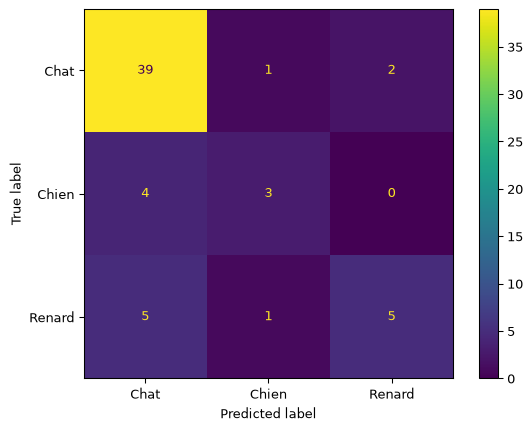

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

# Données d'exemple
y_true = ['Chat'] * 42 + ['Chien'] *  7 + ['Renard'] * 11
y_pred = ['Chat'] * 39 + ['Chien'] *  1 + ['Renard'] *  2 + \
         ['Chat'] *  4 + ['Chien'] *  3 + ['Renard'] *  0 + \
         ['Chat'] *  5 + ['Chien'] *  1 + ['Renard'] *  5

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)

Le jeu de données peut être conceptualisé comme résultant d’une **tâche
de classification d’images**, impliquant des images de **chats**,
**chiens** et **renards**. Reflétant les tendances courantes observées
sur internet, les images de chats sont disproportionnellement
représentées, entraînant un problème de **déséquilibre des classes**.

## Précision micro/macro

In [20]:
from sklearn.metrics import classification_report, precision_score

print(classification_report(y_true, y_pred), "\n")

print("Précision micro : {:.2f}".format(precision_score(y_true, y_pred, average='micro')))
print("Précision macro : {:.2f}".format(precision_score(y_true, y_pred, average='macro')))

              precision    recall  f1-score   support

        Chat       0.81      0.93      0.87        42
       Chien       0.60      0.43      0.50         7
      Renard       0.71      0.45      0.56        11

    accuracy                           0.78        60
   macro avg       0.71      0.60      0.64        60
weighted avg       0.77      0.78      0.77        60
 

Précision micro : 0.78
Précision macro : 0.71

## Précision micro/macro

- La **précision moyenne macro** est calculée comme la moyenne des
  scores de **précision**[1] pour chaque classe :
  $\frac{0.81 + 0.60 + 0.71}{3} = 0.71$.

- Tandis que, la **précision moyenne micro** est calculée en utilisant
  la formule, $\frac{TP}{TP+FP}$ et les **données de toute la matrice de
  confusion** $\frac{39+3+5}{39+3+5+9+2+2} = \frac{47}{60} = 0.78$

La haute précision moyenne micro observée ici est principalement due à
la haute précision et au grand nombre d’exemples dans la classe
majoritaire, Chat. Cela masque la performance relativement médiocre du
classificateur sur les classes minoritaires, Chien et Renard.

Dans un jeu de données équilibré, les métriques micro-moyenne et
macro-moyenne donnent des scores similaires.

Cependant, dans un jeu de données déséquilibré, des différences
significatives dans les performances du classificateur entre les classes
majoritaires et minoritaires entraîneront des scores micro-moyenne et
macro-moyenne divergents. En particulier, le classificateur a tendance à
sous-performer sur les classes minoritaires, conduisant à ces écarts.

Dans les **métriques macro-moyennes**, chaque classe contribue également
au calcul final de la métrique, **indépendamment du nombre d’exemples
qu’elle contient**. Cela signifie que les métriques de performance pour
chaque classe sont calculées indépendamment puis moyennées, sans tenir
compte de la proportion d’instances que chaque classe représente dans le
jeu de données. Par conséquent, la macro-moyenne garantit que **chaque
classe a un impact égal sur la métrique globale**, ce qui peut être
particulièrement utile dans les cas où la distribution des classes est
déséquilibrée.

## Rappel micro/macro

[1] Par conséquent, la précision moyenne macro reste inchangée par le
nombre variable d’exemples dans les différentes classes.

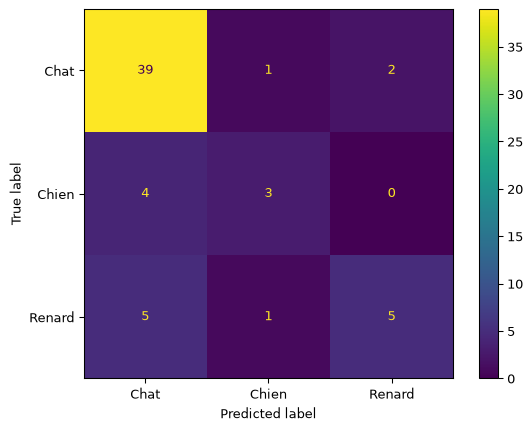

              precision    recall  f1-score   support

        Chat       0.81      0.93      0.87        42
       Chien       0.60      0.43      0.50         7
      Renard       0.71      0.45      0.56        11

    accuracy                           0.78        60
   macro avg       0.71      0.60      0.64        60
weighted avg       0.77      0.78      0.77        60
 

Rappel micro : 0.78
Rappel macro : 0.60

## Rappel micro/macro

- Le **rappel moyen macro** est calculé comme la **moyenne des scores de
  rappel pour chaque classe** : $\frac{0.93 + 0.43 + 0.45}{3} = 0.60$.

- Tandis que, le **rappel moyen micro** est calculé en utilisant la
  formule, $\frac{TP}{TP+FN}$ et les **données de toute la matrice de
  confusion** $\frac{39+3+5}{39+3+5+3+4+6} = \frac{39}{60} = 0.78$

## Exemple

Utilisation du [jeu de données textuelles 20
newsgroups](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html#sklearn.datasets.fetch_20newsgroups)
de [scikit-learn.org](https://scikit-learn.org).

Comprend environ 18 000 articles de newsgroups sur 20 sujets.

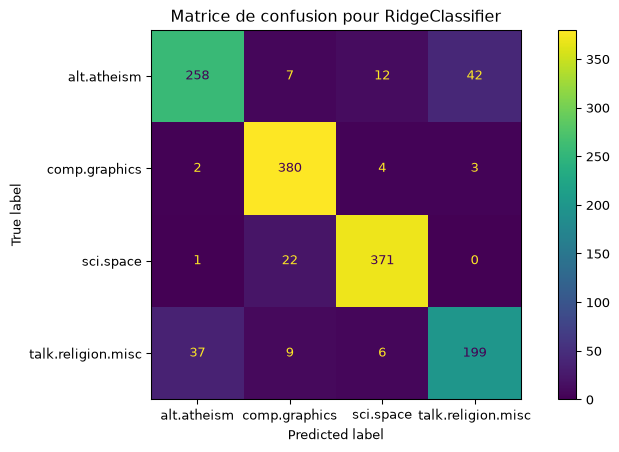

In [23]:
## https://scikit-learn.org/stable/auto_examples/text/plot_document_classification_20newsgroups.html

from time import time

## Charger le jeu de données

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

categories = [
    "alt.atheism",
    "talk.religion.misc",
    "comp.graphics",
    "sci.space",
]

def size_mb(docs):
    return sum(len(s.encode("utf-8")) for s in docs) / 1e6

def load_dataset(verbose=False, remove=()):
    """Charger et vectoriser le jeu de données des 20 newsgroups."""

    data_train = fetch_20newsgroups(
        subset="train",
        categories=categories,
        shuffle=True,
        random_state=42,
        remove=remove,
    )

    data_test = fetch_20newsgroups(
        subset="test",
        categories=categories,
        shuffle=True,
        random_state=42,
        remove=remove,
    )

    # l'ordre des étiquettes dans `target_names` peut être différent de `categories`
    target_names = data_train.target_names

    # diviser la cible en un ensemble d'entraînement et un ensemble de test
    y_train, y_test = data_train.target, data_test.target

    # Extraction des attributs des données d'entraînement à l'aide d'un vectoriseur creux
    t0 = time()
    vectorizer = TfidfVectorizer(
        sublinear_tf=True, max_df=0.5, min_df=5, stop_words="english"
    )
    X_train = vectorizer.fit_transform(data_train.data)
    duration_train = time() - t0

    # Extraction des attributs des données de test en utilisant le même vectoriseur
    t0 = time()
    X_test = vectorizer.transform(data_test.data)
    duration_test = time() - t0

    feature_names = vectorizer.get_feature_names_out()

    if verbose:
        # calculer la taille des données chargées
        data_train_size_mb = size_mb(data_train.data)
        data_test_size_mb = size_mb(data_test.data)

        # print(
        #     f"{len(data_train.data)} documents - "
        #     f"{data_train_size_mb:.2f}MB (ensemble d'entraînement)"
        # )
        # print(f"{len(data_test.data)} documents - {data_test_size_mb:.2f}MB (ensemble de test)")
        # print(f"{len(target_names)} catégories")
        # print(
        #     f"vectorisation de l'entraînement terminée en {duration_train:.3f}s "
        #     f"à {data_train_size_mb / duration_train:.3f}MB/s"
        # )
        # print(f"n_samples: {X_train.shape[0]}, n_features: {X_train.shape[1]}")
        # print(
        #     f"vectorisation du test terminée en {duration_test:.3f}s "
        #     f"à {data_test_size_mb / duration_test:.3f}MB/s"
        # )
        # print(f"n_samples: {X_test.shape[0]}, n_features: {X_test.shape[1]}")

    return X_train, X_test, y_train, y_test, feature_names, target_names

X_train, X_test, y_train, y_test, feature_names, target_names = load_dataset(
    verbose=True
)

## Entraînement et prédiction

from sklearn.linear_model import RidgeClassifier

clf = RidgeClassifier(tol=1e-2, solver="sparse_cg")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

## Afficher la matrice de confusion

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
ax.xaxis.set_ticklabels(target_names)
ax.yaxis.set_ticklabels(target_names)
_ = ax.set_title(
    f"Matrice de confusion pour {clf.__class__.__name__}"
)

## Exemple

In [24]:
cm = confusion_matrix(y_test, y_pred)

## VP, FP, FN, VN

In [25]:
def true_positive(cm, i):
    return cm[i,i] # entrée diagonale i,i

def false_positive(cm, i):
    return np.sum(cm[:, i]) - cm[i,i] # colonne - VP_i

def false_negative(cm, i):
    return np.sum(cm[i, :]) - cm[i,i] # ligne - VP_i

def true_negative(cm, i):
    N = cm.sum()
    TP = true_positive(cm, i)
    FP = false_positive(cm, i)
    FN = false_negative(cm, i)
    return N - (TP + FP + FN)

## Précision

In [26]:
def precision_micro(cm):
    _, l = cm.shape
    tp = fp = 0
    for i in range(l):
        tp += true_positive(cm, i)
        fp += false_positive(cm, i)
    return tp / (tp+fp)

def precision_macro(cm):
    _, l = cm.shape
    precision = 0
    for i in range(l):
        tp = true_positive(cm, i)
        fp = false_positive(cm, i)
        precision += tp/(tp+fp)
    return precision/l

## Précision moyenne micro

$$
  \frac{(258+380+371+199)}{(258+380+371+199)+(40+38+22+45)}
$$ où

- 40 = 2 + 1 + 37
- 38 = 7 + 22 + 9
- 22 = 12 + 4 + 6
- 45 = 42 + 3 + 0

89.28307465 %

## Précision moyenne macro

- $\mathrm{Precision}_0 = \frac{258}{258+(2+1+37)} = 0.8657718121$
- $\mathrm{Precision}_1 = \frac{380}{380+(7+22+9)} = 0.9090909091$
- $\mathrm{Precision}_2 = \frac{371}{371+(12+4+6)} = 0.9440203562$
- $\mathrm{Precision}_3 = \frac{199}{199+(42+3+0)} = 0.8155737705$

$\mathrm{Precision}_3 = \frac{0.8657718121 + 0.9090909091 + 0.9440203562 + 0.8155737705}{4}$

88.3614212 %

## Rappel

In [27]:
def rappel_micro(cm):
    _, l = cm.shape
    tp = fn = 0
    for i in range(l):
        tp += true_positive(cm, i)
        fn += false_negative(cm, i)
    return tp / (tp+fn)

def rappel_macro(cm):
    _, l = cm.shape
    rappel = 0
    for i in range(l):
        tp = true_positive(cm, i)
        fn = false_negative(cm, i)
        rappel += tp / (tp+fn)
    return rappel/l

## Données médicales

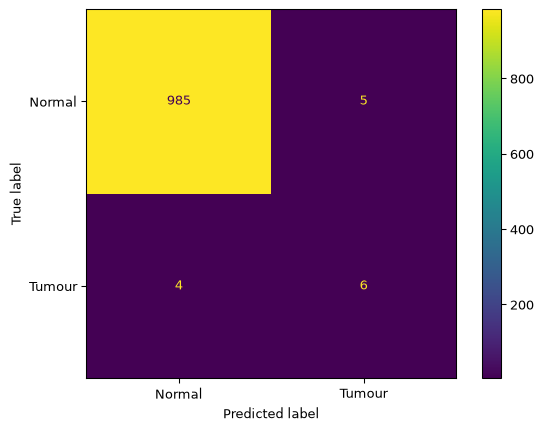

Considérons un ensemble de données médicales, telles que celles
impliquant des tests de diagnostic ou de l’imagerie, comprenant 990
échantillons normaux et 10 échantillons anormaux (tumeur). Cela
représente la vérité terrain.

## Données médicales

              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00       990
      Tumour       0.55      0.60      0.57        10

    accuracy                           0.99      1000
   macro avg       0.77      0.80      0.78      1000
weighted avg       0.99      0.99      0.99      1000
 

Précision micro : 0.99
Précision macro : 0.77


Rappel micro : 0.99
Rappel macro : 0.80

La précision pour la classe `Tumour` est faible. Cependant, en raison de
la petite taille de l’échantillon, cela n’impacte pas significativement
la précision moyennée par micro.

# Compromis précision-rappel

## Chiffres manuscrits (revisités)

Chargement du jeu de données

In [30]:
import numpy as np
np.random.seed(42)

from sklearn.datasets import fetch_openml

digits = fetch_openml('mnist_784', as_frame=False)
X, y = digits.data, digits.target

Tracé des cinq premiers exemples

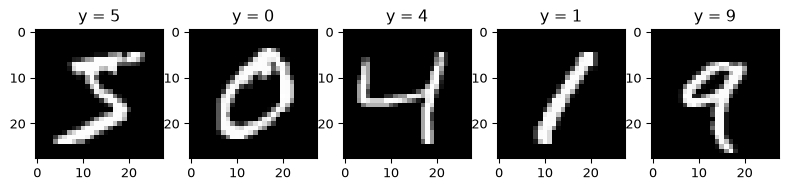

Ces images ont des dimensions de $28 \times 28$ pixels.

## Tâche de classification binaire

In [32]:
# Création d'une tâche de classification binaire (un contre tous)

some_digit = X[0]
some_digit_y = y[0]

y = (y == some_digit_y)
y

array([ True, False, False, ..., False,  True, False], shape=(70000,))

. . .

In [33]:
# Création des ensembles d'entraînement et de test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

## `SGDClassifier`

In [34]:
from sklearn.linear_model import SGDClassifier

clf = SGDClassifier()
clf.fit(X_train, y_train)

clf.predict(X[0:5]) # petite vérification de bon sens

array([False, False, False, False, False])

Le `SGDClassifier` est un classificateur linéaire qui utilise la
descente de gradient stochastique (SGD) pour l’entraînement. Comparé à
`LogisticRegression`, il peut offrir des temps d’entraînement plus
rapides, particulièrement pour les grands ensembles de données. De plus,
`SGDClassifier` permet l’ajustement du seuil de décision dans les
exemples suivants.

## Performance

In [35]:
from sklearn.metrics import accuracy_score

y_pred = clf.predict(X_test)

accuracy_score(y_test, y_pred)

0.9644285714285714

Wow!

## Pas si vite

In [36]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()

dummy_clf.fit(X_train, y_train)

. . .

In [37]:
y_pred = dummy_clf.predict(X_test)

accuracy_score(y_test, y_pred)

0.906

Le
[DummyClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html)
dans scikit-learn génère des prédictions sans tenir compte des attributs
d’entrée. Par défaut, il prédit systématiquement la classe la plus
fréquente dans les données d’entraînement. C’est un classificateur de
base simple.

Pourquoi la précision est-elle si élevée alors que ce classificateur
ignore les données d’entrée ?

La précision élevée est attribuée à la distribution des classes dans le
jeu de données. Environ 10 % des échantillons correspondent au chiffre
‘5’, qui est la classe positive dans notre tâche de classification
binaire. Par conséquent, environ 90 % des échantillons ne sont pas ‘5’
et appartiennent à la classe négative. Comme le DummyClassifier prédit
toujours la classe majoritaire, sa précision est attendue d’être autour
de 90 %.

Cela souligne que la précision n’est souvent pas le meilleur indicateur,
en particulier lorsqu’on traite des jeux de données déséquilibrés.

## Compromis précision-rappel

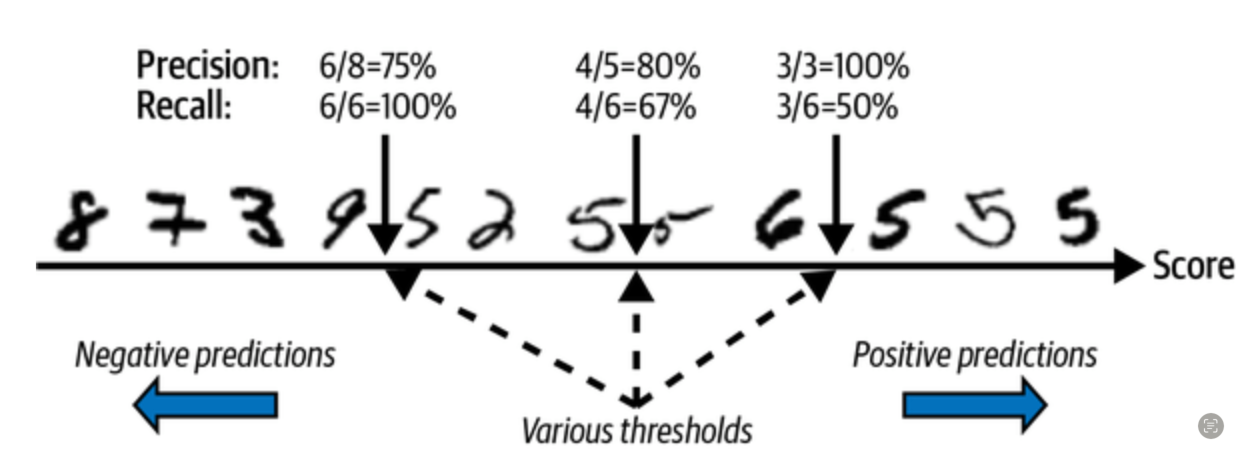

**Attribution** : Géron (2022) Figure 3.4

## Compromis précision-rappel

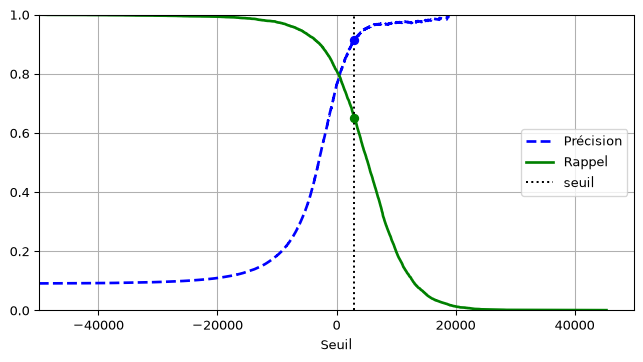

In [38]:
from sklearn.model_selection import cross_val_predict
y_scores = cross_val_predict(clf, X_train, y_train, cv=3, method="decision_function")

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

threshold = 3000

plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Précision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Rappel", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="seuil")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Seuil")
plt.legend(loc="center right")

plt.show()

`SGDClassifier` est utilisé car il permet de faire varier le seuil de
décision (frontière) pour produire un graphique illustrant le compromis
précision-rappel. (Géron 2022)
[`03_classification.ipynb`](https://github.com/ageron/handson-ml3/blob/main/03_classification.ipynb).

À mesure que le seuil de décision diminue, un plus grand nombre
d’exemples sont prédits comme positifs, ce qui peut amener le
classificateur à finalement étiqueter tous les exemples comme positifs.

Inversement, à mesure que le seuil de décision augmente, moins
d’exemples sont classifiés comme positifs, ce qui peut entraîner le
classificateur à ne prédire aucun exemple positif.

Pour certaines applications, un classificateur avec une haute précision
est essentiel. Par exemple, envisagez un scénario où chaque prédiction
nécessite une expérience en laboratoire coûteuse pour vérifier son
exactitude, comme dans une entreprise pharmaceutique cherchant à
découvrir de nouveaux médicaments. Ici, le classificateur prédit si un
composé est actif. Étant donné le coût élevé des expériences pour
valider les candidats, l’entreprise donnerait la priorité aux composés
les plus prometteurs en premier.

En revanche, considérez un scénario de dépistage du cancer, tel que
l’utilisation de mammographies pour détecter le cancer du sein. Dans ce
cas, il peut être préférable d’abaisser le seuil de décision, augmentant
ainsi le nombre de prédictions faussement positives. Bien que cette
approche entraîne plus de patients à subir des tests supplémentaires,
comme des biopsies, elle peut potentiellement sauver plus de vies en
s’assurant que moins de cas de cancer passent inaperçus.

## Courbe précision/rappel

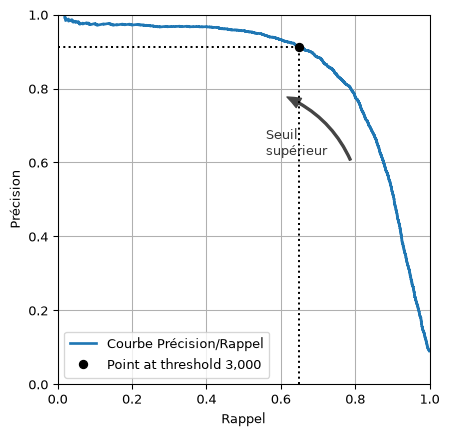

In [39]:
import matplotlib.patches as patches  # extra code – for the curved arrow

plt.figure(figsize=(5, 5))  # extra code – not needed, just formatting

plt.plot(recalls, precisions, linewidth=2, label="Courbe Précision/Rappel")

# extra code – just beautifies and saves Figure 3–6
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Seuil\nsupérieur", color="#333333")
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")

plt.show()

(Géron 2022)
[`03_classification.ipynb`](https://github.com/ageron/handson-ml3/blob/main/03_classification.ipynb).

# Courbe ROC

## Courbe ROC

**Courbe des caractéristiques de fonctionnement du récepteur (ROC)**

- **Taux de vrais positifs** (TVP) contre **taux de faux positifs**
  (TFP)
- Un classificateur idéal a un **TVP** proche de **1.0** et un **TFP**
  proche de **0.0**
- $\mathrm{TVP} = \frac{\mathrm{VP}}{\mathrm{VP}+\mathrm{FN}}$ (rappel,
  sensibilité)
- Le **TVP** s’approche de **un** lorsque le nombre de prédictions
  **faux négatif** est faible
- $\mathrm{TFP} = \frac{\mathrm{FP}}{\mathrm{FP}+\mathrm{VN}}$
  (également appelé~\[1-spécificité\])
- Le **TFP** s’approche de **zéro** lorsque le nombre de **faux
  positifs** est faible

Les courbes ROC (Receiver Operating Characteristic) sont populaires en
apprentissage automatique et en statistiques pour plusieurs raisons :

1.  **Évaluation de la performance complète** : Les courbes ROC offrent
    une représentation visuelle de la performance d’un classificateur à
    travers tous les seuils possibles. En traçant le Taux de Vrais
    Positifs (TVP) contre le Taux de Faux Positifs (TFP), elles
    permettent aux praticiens d’évaluer le compromis entre sensibilité
    (rappel) et spécificité.
2.  **Indépendance au seuil** : Contrairement à des métriques comme la
    précision, les courbes ROC évaluent la performance d’un
    classificateur sans se baser sur un seuil de décision spécifique.
    Cela les rend particulièrement utiles pour comparer des modèles à
    travers différents seuils.
3.  **Surface sous la courbe (AUC)** : La Surface Sous la Courbe ROC
    (AUC) fournit un résumé en valeur unique de la performance du
    modèle. L’AUC-ROC est souvent utilisée comme une métrique de
    référence pour comparer différents modèles, avec des valeurs allant
    de 0.5 (devinette aléatoire) à 1.0 (classification parfaite).
4.  **Applicabilité large** : Les courbes ROC peuvent être utilisées
    pour toute tâche de classification binaire et sont facilement
    étendues aux problèmes multiclasses en utilisant des techniques
    comme la classification un-contre-tous, ce qui les rend polyvalentes
    dans l’évaluation des classificateurs.

## Courbe ROC

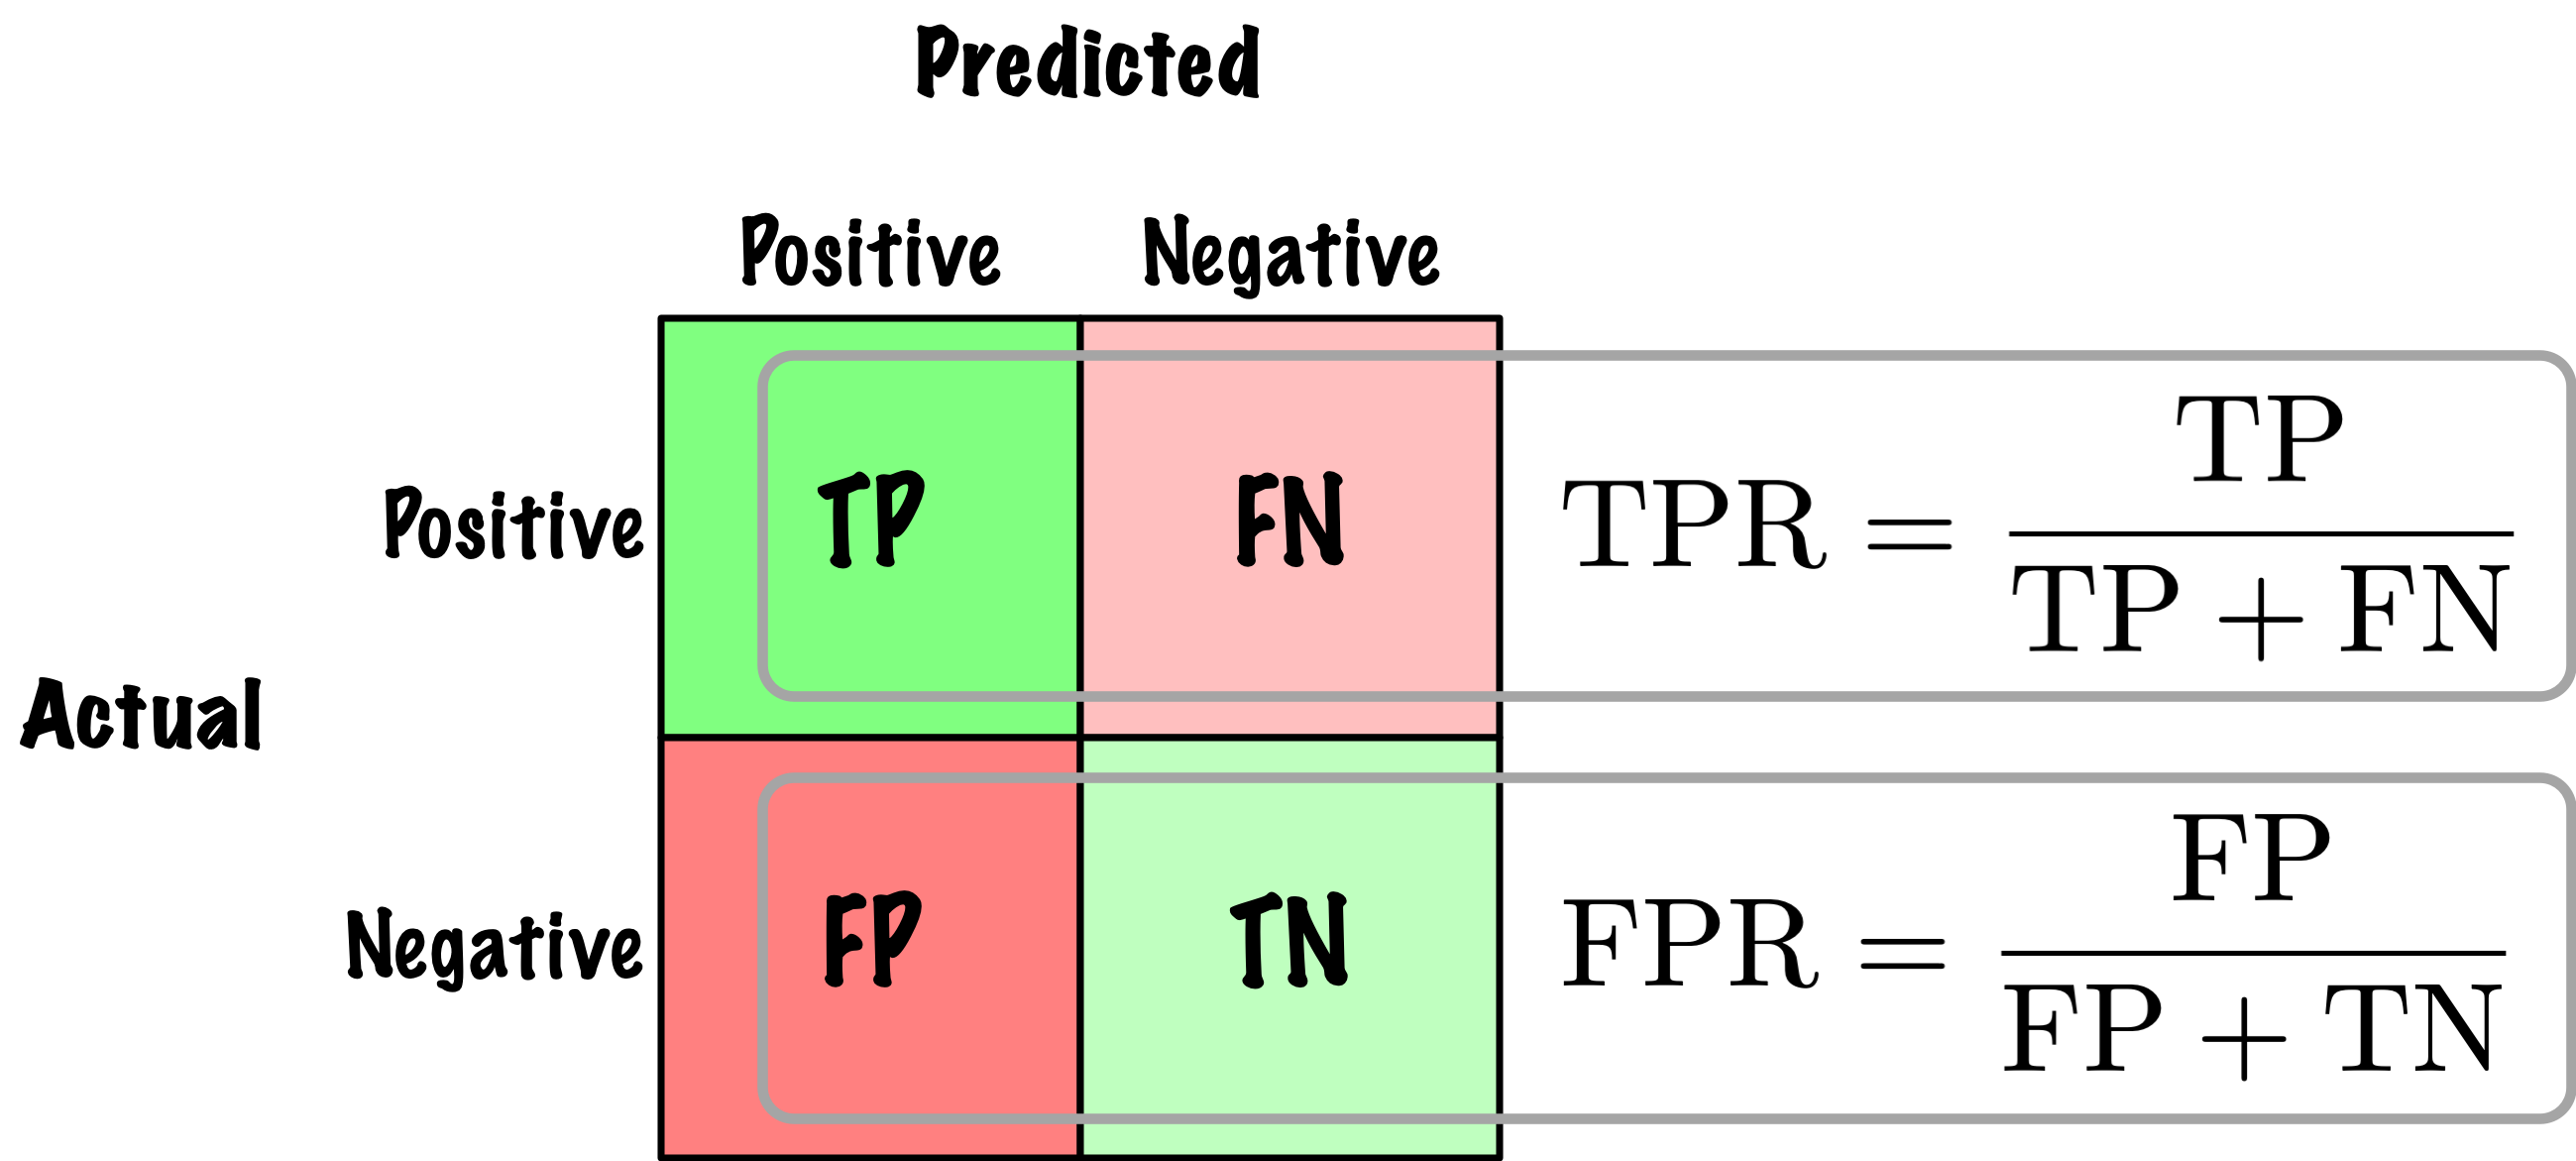

## Courbe ROC

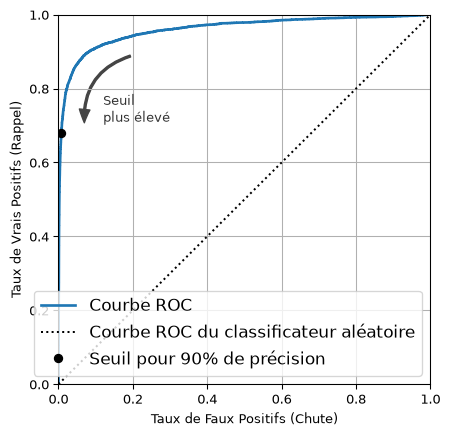

In [40]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train, y_scores)

idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(5, 5))  # code supplémentaire – pas nécessaire, juste pour le formatage
plt.plot(fpr, tpr, linewidth=2, label="Courbe ROC")
plt.plot([0, 1], [0, 1], 'k:', label="Courbe ROC du classificateur aléatoire")
plt.plot([fpr_90], [tpr_90], "ko", label="Seuil pour 90% de précision")

# code supplémentaire – juste pour embellir et enregistrer la Figure 3–7
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Seuil\nplus élevé", color="#333333")
plt.xlabel('Taux de Faux Positifs (Chute)')
plt.ylabel('Taux de Vrais Positifs (Rappel)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)

plt.show()

**Attribution :**
[03_classification.ipynb](https://github.com/ageron/handson-ml3/blob/main/03_classification.ipynb)

Il est courant de mesurer la surface sous la courbe, représentée par
AUC. Plus précisément, la surface sous la courbe ROC. Cela permet de
comparer

## Ensemble de données - openml

>  **[www.openml.org](https://www.openml.org)**
>
> OpenML est une plateforme ouverte pour partager des ensembles de
> données, des algorithmes et des expériences - pour apprendre à mieux
> apprendre, ensemble.

. . .

In [41]:
import numpy as np
np.random.seed(42)

from sklearn.datasets import fetch_openml

diabetes = fetch_openml(name='diabetes', version=1)
print(diabetes.DESCR)

L’ensemble de données d’aujourd’hui est le jeu de données PIMA, qui
contient 768 instances et 8 attributs numériques. La nature numérique de
ces attributs facilite notre analyse. De plus, étant donné que les
données proviennent d’un article publié, elles reflètent probablement
une collecte de données soignée, ce qui pourrait conduire à des
résultats robustes, car les auteurs auraient eu besoin de données de
haute qualité pour soutenir leur publication.

## Jeu de données du diabète des Indiens Pima

In [42]:
from sklearn.datasets import fetch_openml

# Charger le jeu de données du diabète des Indiens Pima
pima = fetch_openml(name='diabetes', version=1, as_frame=True)

# Extraire les attributs et la cible
X = pima.data
y = pima.target

# Convertir les étiquettes cibles 'tested_negative' et 'tested_positive' en 0 et 1
y = y.map({'tested_negative': 0, 'tested_positive': 1})

# Diviser le jeu de données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

[Jeu de données du diabète des Indiens
Pima](https://www.openml.org/search?type=data&sort=version&status=any&order=asc&exact_name=diabetes&id=37)
tel que décrit dans Knowler et al. (1981)
\[[PubMed](https://pubmed.ncbi.nlm.nih.gov/7468572/)\].

## Comparaison de plusieurs classificateurs

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Comparaison de plusieurs classificateurs

In [44]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

Utilisation des paramètres par défaut.

## AUC/ROC

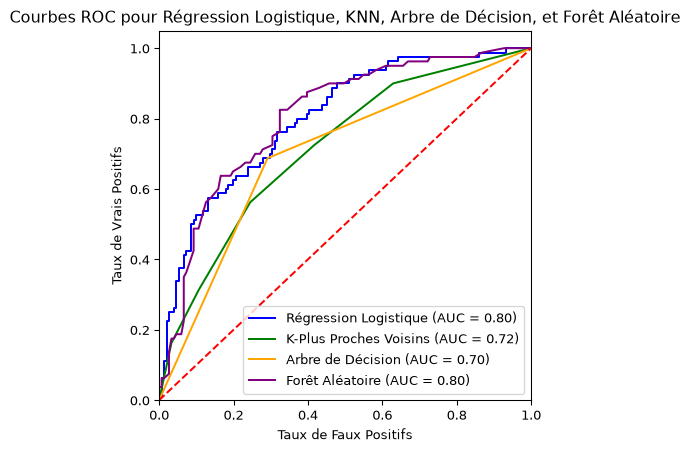

In [45]:
from sklearn.metrics import roc_auc_score

y_pred_prob_lr = lr.predict_proba(X_test)[:, 1]
y_pred_prob_knn = knn.predict_proba(X_test)[:, 1]
y_pred_prob_dt = dt.predict_proba(X_test)[:, 1]
y_pred_prob_rf = rf.predict_proba(X_test)[:, 1]

# Calculer les courbes ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_prob_knn)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)

# Calculer les scores AUC
auc_lr = roc_auc_score(y_test, y_pred_prob_lr)
auc_knn = roc_auc_score(y_test, y_pred_prob_knn)
auc_dt = roc_auc_score(y_test, y_pred_prob_dt)
auc_rf = roc_auc_score(y_test, y_pred_prob_rf)

# Tracer les courbes ROC
plt.figure(figsize=(5, 5)) # plt.figure()
plt.plot(fpr_lr, tpr_lr, color='blue', label=f'Régression Logistique (AUC = {auc_lr:.2f})')
plt.plot(fpr_knn, tpr_knn, color='green', label=f'K-Plus Proches Voisins (AUC = {auc_knn:.2f})')
plt.plot(fpr_dt, tpr_dt, color='orange', label=f'Arbre de Décision (AUC = {auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, color='purple', label=f'Forêt Aléatoire (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Ligne diagonale pour le hasard
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbes ROC pour Régression Logistique, KNN, Arbre de Décision, et Forêt Aléatoire')
plt.legend(loc="lower right")
plt.show()

Les courbes ROC fournissent une représentation visuelle de la
performance d’un classificateur sur **tous les seuils possibles**. En
traçant le Taux de Vrais Positifs (TPR) contre le Taux de Faux Positifs
(FPR), elles permettent aux praticiens d’évaluer le compromis entre
sensibilité (rappel) et spécificité.

Contrairement à des métriques telles que la précision, les courbes ROC
évaluent la performance du classificateur **sans s’appuyer sur un seuil
de décision spécifique**. Cela les rend particulièrement utiles pour
**comparer des modèles sur des seuils variables**.

## Régression logistique

- **Modèle** :

  $$
  h_\theta(x_i) = \sigma(\theta x_i) = \frac{1}{1+e^{- \theta x_i}}
  $$

- **Prédiction** :

  - Assigner $y_i = 0$, si $h_\theta(x_i) < 0.5$ ; $y_i = 1$, si
    $h_\theta(x_i) \geq 0.5$

- **Fonction de perte** : entropie croisée

$$
J(\theta) = - \sum_{i=1}^{N} \left[ y_i \log \sigma(\theta x_i) + (1-y_i) \log (1 - \sigma(\theta x_i)) \right]
$$

Le seuil de décision de 0,5 minimse la valeur de la fonction de perte
pour le jeu de données d’entraînement.

Les courbes ROC évaluent la performance du classificateur **sans
s’appuyer sur un seuil de décision spécifique**. En fait, ces courbes
présentent la variation du TPR en fonction de FPR lorsque l’on fait
varié le seuil de décision.

Parcourons ce qui arrive aux termes de la matrice de confusion lorsque
le seuil de décision passe de 0 à 1.

Au seuil = 0

- Tous prédits positifs.
- VP : tous les positifs réels sont prédits positifs, VP maximal.
- FP : tous les négatifs réels sont prédits positifs, FP maximal.
- $\text{TPR} = 1$ (car $\text{VP} = P$, où $P$ est le total des
  positifs).
- $\text{FPR} = 1$ (car $\text{FP} = N$, où $N$ est le total des
  négatifs).
- Point ROC = $(1,1)$.

À mesure que le seuil augmente de 0 à 1

- Moins d’exemples sont prédits positifs.
- VP diminue (certains positifs ne dépassent plus le seuil).
- FP diminue (certains négatifs ne dépassent plus le seuil).
- TPR diminue de manière monotone de 1 à 0.
- FPR diminue de manière monotone de 1 à 0.
- La courbe trace vers le bas à gauche dans l’espace ROC.

À seuil = 1

- Tous prédits négatifs.
- VP = 0, FP = 0.
- $\text{TPR} = 0$, $\text{FPR} = 0$.
- Point ROC = $(0,0)$.

Intuition sommaire

- Seuil plus bas, plus de positifs prédits, VP et FP augmentent, TPR et
  FPR augmentent.
- Seuil plus haut, plus de négatifs prédits, VP et FP diminuent, TPR et
  FPR diminuent.
- La forme de la courbe ROC dépend de la capacité de la régression
  logistique à séparer les positifs des négatifs :
  - Un modèle parfait monte rapidement vers $(0,1)$.
  - Un modèle aléatoire suit la diagonale.
  - Un modèle réaliste se situe entre les deux.

## Régression logistique

Ci-dessous se trouve notre implémentation de la régression logistique.

In [47]:
def sigmoid(z):
    """Calcule la fonction sigmoïde."""
    return 1 / (1 + np.exp(-z))

def cost_function(theta, X, y):
    """
    Calcule le coût d'entropie croisée binaire.
    theta : vecteur des paramètres
    X : matrice des attributs (chaque ligne est un exemple)
    y : vraies étiquettes binaires (0 ou 1)
    """
    m = len(y)
    h = sigmoid(X.dot(theta))
    # Ajouter un petit epsilon pour éviter log(0)
    epsilon = 1e-5
    cost = -(1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return cost

def gradient(theta, X, y):
    """Calcule le gradient du coût par rapport à theta."""
    m = len(y)
    h = sigmoid(X.dot(theta))
    return (1/m) * X.T.dot(h - y)

def logistic_regression(X, y, learning_rate=0.1, iterations=1000):
    """
    Entraîne la régression logistique en utilisant la descente de gradient.
    Retourne le vecteur des paramètres optimisés theta et l'historique des valeurs de coût.
    """
    m, n = X.shape
    theta = np.zeros(n)
    cost_history = []
    for i in range(iterations):
        theta -= learning_rate * gradient(theta, X, y)
        cost_history.append(cost_function(theta, X, y))
    return theta, cost_history

def predict_probabilities(theta, X):
    """Retourne les probabilités prédites pour la classe positive."""
    return sigmoid(X.dot(theta))

## Implémentation : ROC

In [48]:
def compute_roc_curve(y_true, y_scores, thresholds):
    tpr_list, fpr_list = [], []
    for thresh in thresholds:
        # Classer comme positif si la probabilité prédite >= seuil
        y_pred = (y_scores >= thresh).astype(int)
        TP = np.sum((y_true == 1) & (y_pred == 1))
        FN = np.sum((y_true == 1) & (y_pred == 0))
        FP = np.sum((y_true == 0) & (y_pred == 1))
        TN = np.sum((y_true == 0) & (y_pred == 0))
        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
        tpr_list.append(TPR)
        fpr_list.append(FPR)

    tpr_list.reverse()
    fpr_list.reverse()

    return np.array(fpr_list), np.array(tpr_list)

## Implémentation : AUC ROC

In [49]:
def compute_auc(fpr, tpr):
    """
    Calcule la Surface Sous la Courbe (AUC) en utilisant la règle des trapèzes.
    
    fpr : tableau des taux de faux positifs
    tpr : tableau des taux de vrais positifs
    """
    return np.trapezoid(tpr, fpr)

La **règle des trapèzes** (`trapezoid`), semblable à la **somme de
Riemann**, est une méthode numérique pour approximer l’intégrale définie
d’une fonction. En partitionnant l’aire sous la courbe en trapèzes
plutôt qu’en rectangles, elle offre généralement une approximation plus
précise.

## Générer des données + prédictions

In [50]:
# Générer des données synthétiques pour la classification binaire
np.random.seed(seed)
m = 1000  # nombre d'échantillons
X = np.random.randn(m, 2)
noise = 0.5 * np.random.randn(m)

# Définir les étiquettes : une combinaison linéaire bruitée, seuil à 0
y = (X[:, 0] + X[:, 1] + noise > 0).astype(int)

# Ajouter un terme d'interception (une colonne de uns) à X
X_intercept = np.hstack([np.ones((m, 1)), X])

X_train, X_test, y_train, y_test = train_test_split(X_intercept, y, random_state=seed)

# Entraîner un modèle de régression logistique en utilisant la descente de gradient
theta, cost_history = logistic_regression(X_train, y_train, learning_rate=0.1, iterations=1000)

## Exemple : tracer

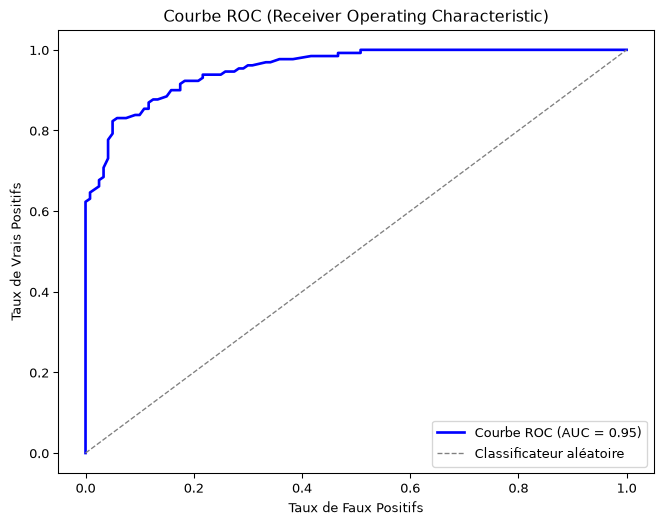

In [51]:
# Calculer les probabilités prédites pour la classe positive sur l'ensemble de test
y_probs = predict_probabilities(theta, X_test)

# Définir un ensemble de valeurs seuils entre 0 et 1 (par exemple, 100 seuils également espacés)
thresholds = np.linspace(0, 1, 100)

# Calculer la courbe ROC (FPR et TPR pour chaque seuil)
fpr, tpr = compute_roc_curve(y_test, y_probs, thresholds)
auc_value = compute_auc(fpr, tpr)

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='Courbe ROC (AUC = %0.2f)' % auc_value)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Classificateur aléatoire')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.show()

## Classificateur aléatoire (simulation)

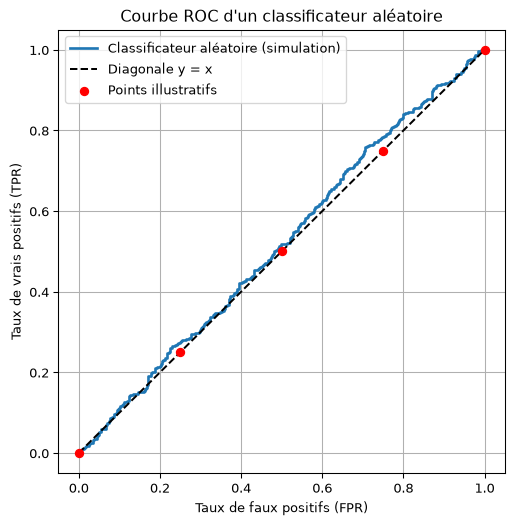

In [52]:
rng = np.random.RandomState(42)

# Simuler les étiquettes (ensemble de données équilibré)

y_true = rng.randint(0, 2, size=1000)  # étiquettes réelles aléatoires

# Simuler des scores aléatoires (indépendants des étiquettes)

y_scores = rng.rand(1000)

# Calculer la courbe ROC

fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Tracer la courbe ROC

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="Classificateur aléatoire (simulation)", lw=2)
plt.plot([0,1],[0,1],'k--', label="Diagonale y = x")
plt.scatter([0,0.25,0.5,0.75,1],[0,0.25,0.5,0.75,1], 
            color="red", zorder=5, label="Points illustratifs")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC d'un classificateur aléatoire")
plt.legend()
plt.grid(True)
plt.show()

## Voir aussi

- [Receiver Operating Characteristic (ROC)
  Multiclasse](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html)
  présente des exemples de courbes micro- et macro- moyennes.

------------------------------------------------------------------------

[hhttps://youtu.be/4jRBRDbJemM](hhttps://youtu.be/4jRBRDbJemM)

La vidéo ci-dessus par StatQuest, Josh Starmer, offre un guide détaillé,
étape par étape, sur la façon de construire et d’analyser les courbes
ROC (Receiver Operating Characteristic).

# Prologue

## Résumé

- Examiné les techniques d’évaluation des modèles de classification, en
  se concentrant sur les matrices de confusion et les métriques clés :
  précision, exactitude, rappel et score $F_1$.
- Abordé les limites de la précision dans les ensembles de données
  déséquilibrés, en introduisant les techniques de moyennage micro et
  macro.
- Exploré le compromis précision-rappel et l’analyse ROC, y compris la
  surface sous la courbe (AUC).
- Fournit des perspectives pratiques à travers des implémentations
  Python.

## Sur les mesures de performance

- Sokolova, M. & Lapalme, G. (2009). A systematic analysis of
  performance measures for classification tasks. *Information Processing
  and Management*, *45*(4), 427–437.
  - Scopus : **4 793 citations**
  - Google Scholar : **7 798 citations**

## Évaluation des algorithmes d’apprentissage

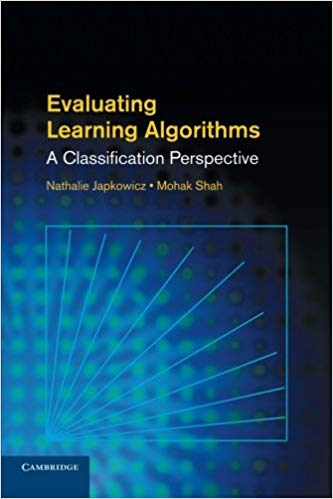

- Ce
  [livre](https://www.cambridge.org/core/books/evaluating-learning-algorithms/3CB22D16AB609D1770C24CA2CB5A11BF),
  avec une note de 4,6 étoiles sur Amazon, explore le processus
  d’évaluation, en mettant particulièrement l’accent sur les algorithmes
  de classification (Japkowicz et Shah 2011).

- [Nathalie
  Japkowicz](https://www.american.edu/cas/faculty/japkowic.cfm) a
  précédemment été professeure à l’Université d’Ottawa et est
  actuellement affiliée à l’American University à Washington.

- [Mohak Shah](http://www.mohakshah.com), qui a obtenu son doctorat à
  l’Université d’Ottawa, a occupé de nombreux postes dans l’industrie, y
  compris Vice-président de l’IA et de l’apprentissage automatique chez
  LG Electronics.

## Prochain cours

- Nous examinerons la validation croisée et le réglage des
  hyperparamètres.

## Références

Géron, Aurélien. 2022. *Hands-on Machine Learning with Scikit-Learn,
Keras, and TensorFlow*. 3ᵉ éd. O’Reilly Media, Inc.

Japkowicz, Nathalie, et Mohak Shah. 2011. *Evaluating Learning
Algorithms: a classification perspective*. Cambridge University Press.

Knowler, William C., David J. Pettitt, Peter J. Savage, et Peter H.
Bennett. 1981. « Diabetes incidence in Pima indians: contributions of
obesity and parental diabetes. » *American journal of epidemiology* 113
2: 144‑56. <https://api.semanticscholar.org/CorpusID:25209675>.

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de **science informatique** et de génie électrique (**SI**GE)

Université d’Ottawa